In [130]:
import pandas as pd

In [131]:
orders = pd.read_csv("C:/Users/A/Downloads/archive/olist_orders_dataset.csv")

In [132]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [133]:
orders.shape

(99441, 8)

In [134]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [135]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [136]:
orders.duplicated().sum()

np.int64(0)

In [137]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [138]:
orders.groupby("order_status")[[
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
]].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [139]:
orders.shape

(99441, 8)

In [140]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [141]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [142]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_carrier_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


In [143]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [144]:
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [145]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [146]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [147]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_carrier_date"].isnull())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


In [148]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [149]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [150]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [151]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [152]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [153]:
orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [154]:
orders["estimated_delivery_days"].describe()

count    99441.000000
mean        23.403958
std          8.829562
min          1.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: estimated_delivery_days, dtype: float64

In [155]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [156]:
print("DATA TYPES")
print(orders[date_columns].dtypes)

print("\nDELIVERY DAYS")
print(orders["delivery_days"].describe())

print("\nESTIMATED DELIVERY DAYS")
print(orders["estimated_delivery_days"].describe())

print("\nDELIVERY DELAY DAYS")
print(orders["delivery_delay_days"].describe())

DATA TYPES
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

DELIVERY DAYS
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

ESTIMATED DELIVERY DAYS
count    99441.000000
mean        23.403958
std          8.829562
min          1.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: estimated_delivery_days, dtype: float64

DELIVERY DELAY DAYS
count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [157]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Early" if x < 0
    else "On Time" if x == 0
    else "Late"
)

In [158]:
orders["delivery_performance"].value_counts()

delivery_performance
Early      88649
Late        9500
On Time     1292
Name: count, dtype: int64

In [159]:
orders["delivery_performance"].value_counts(normalize=True) * 100

delivery_performance
Early      89.147334
Late        9.553404
On Time     1.299263
Name: proportion, dtype: float64

In [160]:
orders.loc[
    orders["delivery_delay_days"] > 0,
    "delivery_delay_days"
].describe()

count    6535.000000
mean       10.620352
std        14.643844
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_delay_days, dtype: float64

In [161]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Early" if x < 0
    else "On Time" if x == 0
    else "Late" if x > 0
    else "Not Delivered"
)

In [162]:
orders["delivery_performance"].value_counts()

delivery_performance
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

In [163]:
orders["delivery_performance"].value_counts(normalize=True) * 100

delivery_performance
Early            89.147334
Late              6.571736
Not Delivered     2.981668
On Time           1.299263
Name: proportion, dtype: float64

In [164]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[ns]')

In [165]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [166]:
orders["order_purchase_timestamp"].dtype

dtype('<M8[ns]')

In [167]:
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [168]:
orders["purchase_month"].head()

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: purchase_month, dtype: period[M]

In [169]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [170]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Early" if x < 0
    else "On Time" if x == 0
    else "Late" if x > 0
    else "Not Delivered"
)

In [171]:
orders["delivery_performance"].value_counts()

delivery_performance
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

In [172]:
monthly_delivery = pd.crosstab(
    orders["purchase_month"],
    orders["delivery_performance"],
    normalize="index"
) * 100

In [173]:
monthly_late = monthly_delivery["Late"].sort_values(ascending=False)

In [174]:
monthly_late.head(10)

purchase_month
2016-09    25.000000
2018-03    18.416308
2018-02    13.778240
2017-11    11.983033
2017-12     7.244844
2018-05     6.445511
2017-04     6.281198
2018-08     6.035012
2018-01     5.544091
2018-04     4.409857
Freq: M, Name: Late, dtype: float64

In [175]:
monthly_orders = orders.groupby("purchase_month").size()

monthly_orders

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

In [176]:
monthly_orders.loc[monthly_late.head(10).index]

purchase_month
2016-09       4
2018-03    7211
2018-02    6728
2017-11    7544
2017-12    5673
2018-05    6873
2017-04    2404
2018-08    6512
2018-01    7269
2018-04    6939
Freq: M, dtype: int64

In [177]:
monthly_late_count = pd.crosstab(
    orders["purchase_month"],
    orders["delivery_performance"]
)["Late"]

monthly_late_count.loc[monthly_late.head(10).index]

purchase_month
2016-09       1
2018-03    1328
2018-02     927
2017-11     904
2017-12     411
2018-05     443
2017-04     151
2018-08     393
2018-01     403
2018-04     306
Freq: M, Name: Late, dtype: int64

In [178]:
meaningful_months = monthly_late[
    monthly_orders.loc[monthly_late.index] >= 1000
]

meaningful_months

purchase_month
2018-03    18.416308
2018-02    13.778240
2017-11    11.983033
2017-12     7.244844
2018-05     6.445511
2017-04     6.281198
2018-08     6.035012
2018-01     5.544091
2018-04     4.409857
2017-03     4.325130
2017-09     4.247375
2017-10     4.038005
2018-07     3.305785
2017-06     2.927581
2017-05     2.864865
2017-08     2.816901
2017-02     2.752809
2017-07     2.682563
2018-06     1.151289
Freq: M, Name: Late, dtype: float64

In [179]:
meaningful_months.sort_values(ascending=False).head(10)

purchase_month
2018-03    18.416308
2018-02    13.778240
2017-11    11.983033
2017-12     7.244844
2018-05     6.445511
2017-04     6.281198
2018-08     6.035012
2018-01     5.544091
2018-04     4.409857
2017-03     4.325130
Freq: M, Name: Late, dtype: float64

In [180]:
order_items = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_items_dataset.csv"
)

In [181]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [182]:
order_items.shape

(112650, 7)

In [183]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [184]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [185]:
sales = order_items.merge(
    orders[["order_id", "order_purchase_timestamp", "order_status"]],
    on="order_id",
    how="left"
)

In [186]:
sales.shape

(112650, 9)

In [187]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,order_status
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02,delivered
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06,delivered
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31,delivered
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35,delivered
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51,delivered


In [188]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

In [189]:
sales[["order_id", "purchase_month", "price", "freight_value"]].head()

,order_id,purchase_month,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,2017-04,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,2018-01,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02,199.90,18.14


In [190]:
monthly_sales = sales.groupby("purchase_month")["price"].sum()

monthly_sales

purchase_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64

In [191]:
monthly_sales.sort_values(ascending=False).head(10)

purchase_month
2017-11    1010271.37
2018-04     996647.75
2018-05     996517.68
2018-03     983213.44
2018-01     950030.36
2018-07     895507.22
2018-06     865124.31
2018-08     854686.33
2018-02     844178.71
2017-12     743914.17
Freq: M, Name: price, dtype: float64

In [192]:
monthly_orders_sales = sales.groupby("purchase_month")["order_id"].nunique()

In [193]:
average_order_value = (
    sales.groupby("order_id")["price"]
    .sum()
    .groupby(sales.groupby("order_id")["purchase_month"].first())
    .mean()
)

In [194]:
monthly_orders_sales

purchase_month
2016-09       3
2016-10     308
2016-12       1
2017-01     789
2017-02    1733
2017-03    2641
2017-04    2391
2017-05    3660
2017-06    3217
2017-07    3969
2017-08    4293
2017-09    4243
2017-10    4568
2017-11    7451
2017-12    5624
2018-01    7220
2018-02    6694
2018-03    7188
2018-04    6934
2018-05    6853
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: order_id, dtype: int64

In [195]:
order_value = sales.groupby(
    ["order_id", "purchase_month"]
)["price"].sum().reset_index(name="order_value")

In [196]:
order_value.head()

,order_id,purchase_month,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09,58.90
1,00018f77f2f0320c557190d7a144bdd3,2017-04,239.90
2,000229ec398224ef6ca0657da4fc703e,2018-01,199.00
3,00024acbcdf0a6daa1e931b038114c75,2018-08,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02,199.90


In [197]:
monthly_aov = order_value.groupby(
    "purchase_month"
)["order_value"].mean()

In [198]:
monthly_aov

purchase_month
2016-09     89.120000
2016-10    160.739156
2016-12     10.900000
2017-01    152.487795
2017-02    142.702262
2017-03    141.743393
2017-04    150.534182
2017-05    138.270803
2017-06    134.609450
2017-07    125.480343
2017-08    133.699436
2017-09    147.160427
2017-10    145.407056
2017-11    135.588695
2017-12    132.274924
2018-01    131.583152
2018-02    126.109756
2018-03    136.785398
2018-04    143.733451
2018-05    145.413349
2018-06    140.442258
2018-07    142.755814
2018-08    132.468433
2018-09    145.000000
Freq: M, Name: order_value, dtype: float64

In [199]:
monthly_aov.sort_values(ascending=False).head(10)

purchase_month
2016-10    160.739156
2017-01    152.487795
2017-04    150.534182
2017-09    147.160427
2018-05    145.413349
2017-10    145.407056
2018-09    145.000000
2018-04    143.733451
2018-07    142.755814
2017-02    142.702262
Freq: M, Name: order_value, dtype: float64

### AOV Insight

Average Order Value (AOV) remained relatively stable across the major
business months, generally ranging between approximately 125 and 150.

The highest meaningful AOV was observed in January 2017 at approximately
152.49, while several high-sales months in 2017–2018 had AOV values closer
to 130–145.

This indicates that strong monthly sales were driven more by higher order
volume than by a substantial increase in the average value of each order.

In [200]:
sales_by_status = (
    sales.groupby("order_status")["price"]
    .agg(["sum", "count"])
    .sort_values("sum", ascending=False)
)

sales_by_status

,sum,count
order_status,,
delivered,13221498.11,110197
shipped,150727.44,1185
canceled,95235.27,542
invoiced,61526.37,359
processing,60439.22,357
unavailable,2007.69,7
approved,209.60,3


In [201]:
delivered_sales = sales.loc[
    sales["order_status"] == "delivered",
    "price"
].sum()

delivered_sales

np.float64(13221498.11)

In [202]:
delivered_orders = sales.loc[
    sales["order_status"] == "delivered",
    "order_id"
].nunique()

delivered_orders

96478

In [203]:
delivered_aov = delivered_sales / delivered_orders

delivered_aov

np.float64(137.0415857501192)

In [204]:
products = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_products_dataset.csv"
)

In [205]:
products.shape

(32951, 9)

In [206]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [207]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [208]:
import pandas as pd

orders = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_orders_dataset.csv"
)

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [209]:
order_items = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_items_dataset.csv"
)

In [210]:
sales = order_items.merge(
    orders[["order_id", "order_purchase_timestamp", "order_status"]],
    on="order_id",
    how="left"
)

In [211]:
sales["purchase_month"] = sales["order_purchase_timestamp"].dt.to_period("M")

In [212]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [213]:
sales.shape

(112650, 11)

In [214]:
sales["product_category_name"].isna().sum()

np.int64(1603)

In [215]:
sales["product_category_name"].nunique()

73

In [216]:
category_sales = (
    sales[sales["order_status"] == "delivered"]
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

product_category_name
beleza_saude              1233131.72
relogios_presentes        1166176.98
cama_mesa_banho           1023434.76
esporte_lazer              954852.55
informatica_acessorios     888724.61
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578966.65
brinquedos                 471286.48
Name: price, dtype: float64

In [217]:
category_sales_percentage = (
    category_sales / category_sales.sum() * 100
)

category_sales_percentage.head(10)

product_category_name
beleza_saude              9.448727
relogios_presentes        8.935694
cama_mesa_banho           7.841948
esporte_lazer             7.316445
informatica_acessorios    6.809748
moveis_decoracao          5.455062
utilidades_domesticas     4.717182
cool_stuff                4.675617
automotivo                4.436264
brinquedos                3.611177
Name: price, dtype: float64

In [218]:
top_5_share = category_sales_percentage.head(5).sum()

top_5_share

np.float64(40.35256174756037)

In [219]:
category_orders = (
    sales[sales["order_status"] == "delivered"]
    .groupby("product_category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

category_orders.head(10)

product_category_name
cama_mesa_banho           9272
beleza_saude              8647
esporte_lazer             7530
informatica_acessorios    6530
moveis_decoracao          6307
utilidades_domesticas     5743
relogios_presentes        5495
telefonia                 4093
automotivo                3810
brinquedos                3804
Name: order_id, dtype: int64

In [220]:
category_aov = (
    category_sales / category_orders
).sort_values(ascending=False)

category_aov.head(10)

product_category_name
pcs                                              1235.503616
portateis_casa_forno_e_cafe                       647.077222
eletrodomesticos_2                                475.568062
agro_industria_e_comercio                         398.678531
portateis_cozinha_e_preparadores_de_alimentos     302.586923
instrumentos_musicais                             301.662422
eletroportateis                                   300.088867
telefonia_fixa                                    260.920802
construcao_ferramentas_seguranca                  243.856730
climatizacao                                      216.762439
dtype: float64

In [221]:
category_summary = pd.DataFrame({
    "sales_value": category_sales,
    "orders": category_orders,
    "aov": category_aov
})

category_summary.sort_values(
    "aov",
    ascending=False
).head(15)

,sales_value,orders,aov
product_category_name,,,
pcs,218684.14,177,1235.503616
portateis_casa_forno_e_cafe,46589.56,72,647.077222
eletrodomesticos_2,107953.95,227,475.568062
agro_industria_e_comercio,70566.10,177,398.678531
portateis_cozinha_e_preparadores_de_alimentos,3933.63,13,302.586923
instrumentos_musicais,184315.74,611,301.662422
eletroportateis,182754.12,609,300.088867
telefonia_fixa,55315.21,212,260.920802
construcao_ferramentas_seguranca,38773.22,159,243.856730


In [222]:
category_translation = pd.read_csv(
    "C:/Users/A/Downloads/archive/product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [223]:
category_translation.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [224]:
sales = sales.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [225]:
sales.shape

(112650, 12)

In [226]:
sales["product_category_name_english"].isna().sum()

np.int64(1627)

In [227]:
sales[
    ["product_category_name", "product_category_name_english"]
].drop_duplicates().head(15)

,product_category_name,product_category_name_english
0,cool_stuff,cool_stuff
1,pet_shop,pet_shop
2,moveis_decoracao,furniture_decor
3,perfumaria,perfumery
4,ferramentas_jardim,garden_tools
5,utilidades_domesticas,housewares
6,telefonia,telephony
8,beleza_saude,health_beauty
9,livros_tecnicos,books_technical
11,fashion_bolsas_e_acessorios,fashion_bags_accessories


In [228]:
missing_translation = (
    sales.loc[
        sales["product_category_name"].notna()
        & sales["product_category_name_english"].isna(),
        "product_category_name"
    ]
    .value_counts()
)

missing_translation

product_category_name
portateis_cozinha_e_preparadores_de_alimentos    15
pc_gamer                                          9
Name: count, dtype: int64

In [229]:
missing_translation.index.tolist()

['portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer']

In [230]:
sales["category_english"] = sales["product_category_name_english"]

sales.loc[
    sales["product_category_name"] == "portateis_cozinha_e_preparadores_de_alimentos",
    "category_english"
] = "portable_kitchen_food_preparers"

sales.loc[
    sales["product_category_name"] == "pc_gamer",
    "category_english"
] = "gaming_pc"

In [231]:
sales["category_english"].isna().sum()

np.int64(1603)

In [232]:
category_summary = (
    sales[sales["order_status"] == "delivered"]
    .dropna(subset=["category_english"])
    .groupby("category_english")
    .agg(
        sales_value=("price", "sum"),
        orders=("order_id", "nunique")
    )
)

category_summary["aov"] = (
    category_summary["sales_value"] /
    category_summary["orders"]
)

category_summary = category_summary.sort_values(
    "sales_value",
    ascending=False
)

category_summary.head(10)

,sales_value,orders,aov
category_english,,,
health_beauty,1233131.72,8647,142.608040
watches_gifts,1166176.98,5495,212.225110
bed_bath_table,1023434.76,9272,110.379072
sports_leisure,954852.55,7530,126.806448
computers_accessories,888724.61,6530,136.098715
furniture_decor,711927.69,6307,112.878974
housewares,615628.69,5743,107.196359
cool_stuff,610204.10,3559,171.453807
auto,578966.65,3810,151.959751


In [233]:
category_summary.head(10).round(2)

,sales_value,orders,aov
category_english,,,
health_beauty,1233131.72,8647,142.61
watches_gifts,1166176.98,5495,212.23
bed_bath_table,1023434.76,9272,110.38
sports_leisure,954852.55,7530,126.81
computers_accessories,888724.61,6530,136.10
furniture_decor,711927.69,6307,112.88
housewares,615628.69,5743,107.20
cool_stuff,610204.10,3559,171.45
auto,578966.65,3810,151.96


In [234]:
product_sales = (
    sales[sales["order_status"] == "delivered"]
    .groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

product_id
bb50f2e236e5eea0100680137654686c    63560.00
6cdd53843498f92890544667809f1595    53652.30
d6160fb7873f184099d9bc95e30376af    45949.35
d1c427060a0f73f6b889a5c7c61f2ac4    45620.56
99a4788cb24856965c36a24e339b6058    42049.66
3dd2a17168ec895c781a9191c1e95ad7    40782.80
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37454.63
aca2eb7d00ea1a7b8ebd4e68314663af    37104.30
Name: price, dtype: float64

In [235]:
product_orders = (
    sales[sales["order_status"] == "delivered"]
    .groupby("product_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

product_orders.head(10)

product_id
99a4788cb24856965c36a24e339b6058    456
aca2eb7d00ea1a7b8ebd4e68314663af    425
422879e10f46682990de24d770e7f83d    352
d1c427060a0f73f6b889a5c7c61f2ac4    313
389d119b48cf3043d311335e499d9c6b    309
53b36df67ebb7c41585e8d54d6772e08    304
368c6c730842d78016ad823897a372db    291
53759a2ecddad2bb87a079a1f1519f73    287
154e7e31ebfa092203795c972e5804a6    262
2b4609f8948be18874494203496bc318    254
Name: order_id, dtype: int64

In [236]:
product_summary = (
    sales[sales["order_status"] == "delivered"]
    .groupby("product_id")
    .agg(
        sales_value=("price", "sum"),
        orders=("order_id", "nunique")
    )
)

product_summary["aov"] = (
    product_summary["sales_value"] /
    product_summary["orders"]
)

product_summary = product_summary.sort_values(
    "sales_value",
    ascending=False
)

product_summary.head(10)

,sales_value,orders,aov
product_id,,,
bb50f2e236e5eea0100680137654686c,63560.00,186,341.720430
6cdd53843498f92890544667809f1595,53652.30,148,362.515541
d6160fb7873f184099d9bc95e30376af,45949.35,33,1392.404545
d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,313,145.752588
99a4788cb24856965c36a24e339b6058,42049.66,456,92.214167
3dd2a17168ec895c781a9191c1e95ad7,40782.80,253,161.196838
25c38557cf793876c5abdd5931f922db,38907.32,38,1023.876842
5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,598.950794
53b36df67ebb7c41585e8d54d6772e08,37454.63,304,123.206020


In [237]:
product_summary.head(10).round(2)

,sales_value,orders,aov
product_id,,,
bb50f2e236e5eea0100680137654686c,63560.00,186,341.72
6cdd53843498f92890544667809f1595,53652.30,148,362.52
d6160fb7873f184099d9bc95e30376af,45949.35,33,1392.40
d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,313,145.75
99a4788cb24856965c36a24e339b6058,42049.66,456,92.21
3dd2a17168ec895c781a9191c1e95ad7,40782.80,253,161.20
25c38557cf793876c5abdd5931f922db,38907.32,38,1023.88
5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,598.95
53b36df67ebb7c41585e8d54d6772e08,37454.63,304,123.21


In [238]:
orders["customer_id"].nunique()

99441

In [239]:
orders["order_id"].nunique()

99441

In [240]:
orders["customer_id"].duplicated().sum()

np.int64(0)

In [241]:
customers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_customers_dataset.csv"
)

In [242]:
customers.shape

(99441, 5)

In [243]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [244]:
customers["customer_unique_id"].nunique()

96096

In [245]:
customers["customer_id"].nunique()

99441

In [246]:
orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [247]:
orders.shape

(99441, 9)

In [248]:
customer_orders = (
    orders.groupby("customer_unique_id")["order_id"]
    .nunique()
)

In [249]:
customer_orders.value_counts().sort_index()

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [250]:
total_customers = customer_orders.shape[0]

repeat_customers = (customer_orders > 1).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("Total unique customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat customer rate:", repeat_customer_rate)

Total unique customers: 96096
Repeat customers: 2997
Repeat customer rate: 3.1187562437562435


In [251]:
one_time_customers = (customer_orders == 1).sum()

one_time_customer_rate = (
    one_time_customers / total_customers
) * 100

print("One-time customers:", one_time_customers)
print("One-time customer rate:", one_time_customer_rate)

One-time customers: 93099
One-time customer rate: 96.88124375624375


In [252]:
customer_frequency = (
    customer_orders.value_counts()
    .sort_index()
)

print(customer_frequency)

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


In [253]:
repeat_customer_orders = customer_orders[
    customer_orders > 1
]

print(
    "Average orders per repeat customer:",
    repeat_customer_orders.mean()
)

print(
    "Maximum orders by a customer:",
    customer_orders.max()
)

Average orders per repeat customer: 2.116116116116116
Maximum orders by a customer: 17


In [254]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [255]:
state_customers = (
    customers.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(state_customers)

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
MS      694
PB      519
PI      482
RN      474
AL      401
SE      342
TO      273
RO      240
AM      143
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64


In [256]:
print(state_customers.head(10))

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64


In [257]:
state_customer_share = (
    state_customers / state_customers.sum()
) * 100

print(state_customer_share.head(10))

customer_state
SP    41.921861
RJ    12.881751
MG    11.711534
RS     5.489099
PR     5.078223
SC     3.676042
BA     3.408713
DF     2.158401
ES     2.042939
GO     2.030457
Name: customer_unique_id, dtype: float64


In [258]:
sales = sales.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

In [259]:
print(sales.shape)
print(sales.columns)

(112650, 14)
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'order_purchase_timestamp', 'order_status', 'purchase_month',
       'product_category_name', 'product_category_name_english',
       'category_english', 'customer_id'],
      dtype='object')


In [260]:
sales = sales.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

In [261]:
print(sales.shape)
print(sales["customer_state"].isna().sum())

(112650, 15)
0


In [264]:
sales = sales.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

In [265]:
[c for c in sales.columns if "customer" in c]

['customer_id', 'customer_state_x', 'customer_state_y', 'customer_state']

In [266]:
print(
    (sales["customer_state_x"] == sales["customer_state_y"]).all()
)

True


In [ ]:
print("Missing in x:", sales["customer_state_x"].isna().sum())
print("Missing in y:", sales["customer_state_y"].isna().sum())

In [267]:
sales["customer_state"] = sales["customer_state_x"]

sales = sales.drop(
    columns=["customer_state_x", "customer_state_y"]
)

In [268]:
print(sales.shape)
print(sales["customer_state"].isna().sum())

(112650, 15)
0


In [269]:
state_sales = (
    sales[sales["order_status"] == "delivered"]
    .groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))

customer_state
SP    5067633.16
RJ    1759651.13
MG    1552481.83
RS     728897.47
PR     666063.51
SC     507012.13
BA     493584.14
DF     296498.41
GO     282836.70
ES     268643.45
Name: price, dtype: float64


In [270]:
state_sales_share = (
    state_sales / state_sales.sum()
) * 100

print(state_sales_share.head(10))

customer_state
SP    38.328736
RJ    13.309015
MG    11.742102
RS     5.512972
PR     5.037731
SC     3.834756
BA     3.733194
DF     2.242548
GO     2.139218
ES     2.031868
Name: price, dtype: float64


In [271]:
state_sales_per_customer = (
    state_sales / state_customers
).sort_values(ascending=False)

print(state_sales_per_customer.head(10))

customer_state
PB    216.930289
AC    206.895714
AP    199.624030
AL    196.647681
RO    190.344833
PA    183.846776
TO    177.298571
PI    175.769710
MT    173.734726
RN    173.218692
dtype: float64


In [272]:
state_analysis = pd.DataFrame({
    "customers": state_customers,
    "sales": state_sales,
    "sales_per_customer": state_sales_per_customer
})

state_analysis = state_analysis[
    state_analysis["customers"] >= 1000
].sort_values(
    "sales_per_customer",
    ascending=False
)

print(state_analysis)

                customers       sales  sales_per_customer
customer_state                                           
CE                   1313   219757.38          167.370434
PE                   1609   251889.49          156.550336
BA                   3277   493584.14          150.620732
GO                   1952   282836.70          144.895850
SC                   3534   507012.13          143.466930
DF                   2075   296498.41          142.890800
RJ                  12384  1759651.13          142.090692
RS                   5277   728897.47          138.127245
MG                  11259  1552481.83          137.888074
ES                   1964   268643.45          136.783834
PR                   4882   666063.51          136.432509
SP                  40302  5067633.16          125.741481


In [273]:
payments = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_payments_dataset.csv"
)

payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [274]:
payments.shape

(103886, 5)

In [275]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [276]:
payment_type_counts = (
    payments["payment_type"]
    .value_counts()
)

print(payment_type_counts)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [277]:
payment_type_share = (
    payments["payment_type"].value_counts(normalize=True) * 100
)

print(payment_type_share)

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64


In [278]:
payment_value_by_type = (
    payments.groupby("payment_type")["payment_value"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

print(payment_value_by_type)

                      sum        mean  count
payment_type                                
credit_card   12542084.19  163.319021  76795
boleto         2869361.27  145.034435  19784
voucher         379436.87   65.703354   5775
debit_card      217989.79  142.570170   1529
not_defined          0.00    0.000000      3


In [279]:
installment_counts = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

print(installment_counts)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64


In [280]:
installment_share = (
    payments["payment_installments"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(installment_share)

payment_installments
0      0.001925
1     50.580444
2     11.948675
3     10.069692
4      6.832489
5      5.043028
6      3.773367
7      1.565177
8      4.108350
9      0.619910
10     5.128699
11     0.022140
12     0.128025
13     0.015401
14     0.014439
15     0.071232
16     0.004813
17     0.007701
18     0.025990
20     0.016364
21     0.002888
22     0.000963
23     0.000963
24     0.017327
Name: proportion, dtype: float64


In [281]:
def installment_group(x):
    if x == 1:
        return "1 installment"
    elif 2 <= x <= 3:
        return "2-3 installments"
    elif 4 <= x <= 6:
        return "4-6 installments"
    elif 7 <= x <= 12:
        return "7-12 installments"
    else:
        return "13+ installments"

payments["installment_group"] = payments["payment_installments"].apply(
    installment_group
)

installment_group_share = (
    payments["installment_group"]
    .value_counts(normalize=True)
    * 100
)

print(installment_group_share)

installment_group
1 installment        50.580444
2-3 installments     22.018366
4-6 installments     15.648884
7-12 installments    11.572300
13+ installments      0.180005
Name: proportion, dtype: float64


In [282]:
credit_card_installments = payments[
    payments["payment_type"] == "credit_card"
]["payment_installments"]

print(
    credit_card_installments
    .value_counts(normalize=True)
    .sort_index() * 100
)

payment_installments
0      0.002604
1     33.146689
2     16.163813
3     13.621981
4      9.242789
5      6.822059
6      5.104499
7      2.117325
8      5.557653
9      0.838596
10     6.937952
11     0.029950
12     0.173188
13     0.020835
14     0.019533
15     0.096360
16     0.006511
17     0.010417
18     0.035159
20     0.022137
21     0.003907
22     0.001302
23     0.001302
24     0.023439
Name: proportion, dtype: float64


In [283]:
reviews = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [284]:
print(reviews.shape)
print(reviews.columns)

(99224, 7)
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')


In [285]:
review_score_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

print(review_score_counts)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [286]:
review_score_share = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(review_score_share)

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64


In [287]:
average_review_score = reviews["review_score"].mean()

print(average_review_score)

4.08642062404257


In [288]:
def review_group(score):
    if score <= 2:
        return "Low (1-2)"
    elif score == 3:
        return "Neutral (3)"
    else:
        return "Positive (4-5)"

reviews["review_group"] = reviews["review_score"].apply(review_group)

review_group_share = (
    reviews["review_group"]
    .value_counts(normalize=True)
    * 100
)

print(review_group_share)

review_group
Positive (4-5)    77.068048
Low (1-2)         14.688987
Neutral (3)        8.242965
Name: proportion, dtype: float64


In [290]:
print(orders.columns.tolist())


['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id']


In [291]:
print(orders.shape)

(99441, 9)


In [292]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [293]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Early" if x < 0
    else "On Time" if x == 0
    else "Late" if x > 0
    else "Not Delivered"
)

In [294]:
print(orders[[
    "order_id",
    "delivery_delay_days",
    "delivery_performance"
]].head())

                           order_id  delivery_delay_days delivery_performance
0  e481f51cbdc54678b7cc49136f2d6af7                 -8.0                Early
1  53cdb2fc8bc7dce0b6741e2150273451                 -6.0                Early
2  47770eb9100c2d0c44946d9cf07ec65d                -18.0                Early
3  949d5b44dbf5de918fe9c16f97b45f8a                -13.0                Early
4  ad21c59c0840e6cb83a9ceb5573f8159                -10.0                Early


In [295]:
print(orders["delivery_performance"].value_counts())

delivery_performance
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64


In [296]:
review_delivery = reviews.merge(
    orders[
        [
            "order_id",
            "delivery_performance",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

print(review_delivery.shape)

(99224, 10)


In [297]:
delivery_review_score = (
    review_delivery
    .groupby("delivery_performance")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

print(delivery_review_score)

                          mean  count
delivery_performance                 
Not Delivered         1.761257   2865
Late                  2.271139   6410
On Time               4.033308   1291
Early                 4.293578  88658


In [298]:
delivery_review_distribution = (
    pd.crosstab(
        review_delivery["delivery_performance"],
        review_delivery["review_score"],
        normalize="index"
    ) * 100
)

print(delivery_review_distribution.round(2))

review_score              1     2      3      4      5
delivery_performance                                  
Early                  6.60  2.63   7.99  20.34  62.43
Late                  53.73  8.67  10.89  10.17  16.54
Not Delivered         70.33  7.33   7.57   5.41   9.35
On Time                8.52  3.87  13.79  23.39  50.43


In [299]:
late_reviews = review_delivery[
    review_delivery["delivery_performance"] == "Late"
].copy()

In [300]:
late_reviews["delay_bucket"] = pd.cut(
    late_reviews["delivery_delay_days"],
    bins=[0, 3, 7, 14, float("inf")],
    labels=["1-3 days", "4-7 days", "8-14 days", "15+ days"]
)

In [301]:
delay_review_score = (
    late_reviews
    .groupby("delay_bucket", observed=True)["review_score"]
    .agg(["mean", "count"])
)

print(delay_review_score.round(2))

              mean  count
delay_bucket             
1-3 days      3.29   1856
4-7 days      2.10   1756
8-14 days     1.68   1453
15+ days      1.72   1345


In [302]:
category_review_score = (
    review_delivery
    .merge(
        sales[["order_id", "category_english"]].drop_duplicates("order_id"),
        on="order_id",
        how="left"
    )
    .groupby("category_english")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

print(category_review_score.head(10).round(2))

                                   mean  count
category_english                              
security_and_services              2.50      2
portable_kitchen_food_preparers    3.43     14
gaming_pc                          3.43      7
office_furniture                   3.62   1260
fashion_male_clothing              3.70    111
fashio_female_clothing             3.73     41
diapers_and_hygiene                3.74     27
furniture_mattress_and_upholstery  3.82     38
audio                              3.83    344
home_confort                       3.88    376


In [303]:
print(sales.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'order_purchase_timestamp', 'order_status', 'purchase_month', 'product_category_name', 'product_category_name_english', 'category_english', 'customer_id', 'customer_state']


In [304]:
print(sales.shape)

(112650, 15)


In [305]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

print(sales.shape)

(112650, 16)


In [307]:
sales["category_english"] = sales["product_category_name_english"]

In [ ]:
print(sales["category_english"].isna().sum())

In [309]:
category_review_score = (
    review_delivery
    .merge(
        sales[["order_id", "category_english"]].drop_duplicates("order_id"),
        on="order_id",
        how="left"
    )
    .groupby("category_english")["review_score"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

print(category_review_score.head(10).round(2))

                                   mean  count
category_english                              
security_and_services              2.50      2
office_furniture                   3.62   1260
fashion_male_clothing              3.70    111
fashio_female_clothing             3.73     41
diapers_and_hygiene                3.74     27
furniture_mattress_and_upholstery  3.82     38
audio                              3.83    344
home_confort                       3.88    376
construction_tools_safety          3.89    161
fixed_telephony                    3.90    215


In [310]:
print(category_review_score.tail(10).round(2))

                           mean  count
category_english                      
books_imported             4.38     52
food_drink                 4.39    225
flowers                    4.39     28
books_technical            4.40    258
fashion_sport              4.42     26
costruction_tools_tools    4.43     94
books_general_interest     4.47    505
fashion_childrens_clothes  4.50      8
la_cuisine                 4.55     11
cds_dvds_musicals          4.67     12


In [311]:
category_review_reliable = category_review_score[
    category_review_score["count"] >= 100
].sort_values("mean")

In [312]:
print(category_review_reliable.head(10).round(2))

                           mean  count
category_english                      
office_furniture           3.62   1260
fashion_male_clothing      3.70    111
audio                      3.83    344
home_confort               3.88    376
construction_tools_safety  3.89    161
fixed_telephony            3.90    215
fashion_underwear_beach    3.93    120
bed_bath_table             3.98   9323
telephony                  4.01   4156
furniture_decor            4.02   6362


In [313]:
print(category_review_reliable.tail(10).round(2))

                                mean  count
category_english                           
industry_commerce_and_business  4.21    231
fashion_shoes                   4.22    237
costruction_tools_garden        4.23    189
pet_shop                        4.25   1697
stationery                      4.25   2285
food                            4.27    439
luggage_accessories             4.34   1019
food_drink                      4.39    225
books_technical                 4.40    258
books_general_interest          4.47    505


In [314]:
# Keep only orders that contain exactly one product category
order_category_counts = (
    sales.groupby("order_id")["category_english"]
    .nunique()
)

single_category_orders = order_category_counts[
    order_category_counts == 1
].index

# Filter reviews to those single-category orders
review_category = review_delivery[
    review_delivery["order_id"].isin(single_category_orders)
].merge(
    sales[["order_id", "category_english"]].dropna(),
    on="order_id",
    how="left"
)

# Category-level review analysis
category_review_score = (
    review_category
    .groupby("category_english")["review_score"]
    .agg(["mean", "count"])
)

# Use a minimum of 100 reviews for reliable comparison
category_review_reliable = (
    category_review_score[
        category_review_score["count"] >= 100
    ]
    .sort_values("mean")
)

print(category_review_reliable.head(10).round(2))
print()
print(category_review_reliable.tail(10).round(2))

                           mean  count
category_english                      
office_furniture           3.51   1666
fashion_male_clothing      3.64    131
fixed_telephony            3.67    260
audio                      3.84    355
construction_tools_safety  3.88    185
bed_bath_table             3.91  10884
home_confort               3.92    379
computers_accessories      3.94   7784
furniture_decor            3.94   8053
furniture_living_room      3.94    485

                        mean  count
category_english                   
cool_stuff              4.17   3704
computers               4.19    199
pet_shop                4.19   1928
stationery              4.21   2475
food                    4.22    486
fashion_shoes           4.24    259
food_drink              4.31    274
luggage_accessories     4.32   1072
books_technical         4.39    262
books_general_interest  4.45    544


### Category-Level Customer Satisfaction

Customer satisfaction varied considerably across product categories.

Among categories with at least 100 review records, Office Furniture recorded the lowest average review score at 3.51/5 based on 1,666 reviews. Fashion Male Clothing and Fixed Telephony followed with average scores of 3.64 and 3.67 respectively.

At the higher end, Books - General Interest recorded an average review score of 4.45/5 from 544 reviews, followed by Books - Technical at 4.39/5 and Food & Drink at 4.31/5.

This indicates that customer satisfaction differed across product categories. However, these results represent associations and do not establish that the product category itself caused the differences in customer ratings.

In [315]:
sellers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_sellers_dataset.csv"
)

print(sellers.shape)
print(sellers.columns)

(3095, 4)
Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')


In [316]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [317]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [318]:
sellers["seller_id"].nunique()

3095

In [319]:
seller_sales = (
    sales[sales["order_status"] == "delivered"]
    .groupby("seller_id")
    .agg(
        sales_value=("price", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count")
    )
    .sort_values("sales_value", ascending=False)
)

seller_sales.head(10)

,sales_value,orders,items_sold
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,1148
53243585a1d6dc2643021fd1853d8905,217940.44,348,400
4a3ca9315b744ce9f8e9374361493884,196882.12,1772,1949
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,579
7c67e1448b00f6e969d365cea6b010ab,186570.05,973,1355
7e93a43ef30c4f03f38b393420bc753a,165981.49,319,322
da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,1548
7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,1155
1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,1420


In [320]:
seller_sales.head(10)

,sales_value,orders,items_sold
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,1148
53243585a1d6dc2643021fd1853d8905,217940.44,348,400
4a3ca9315b744ce9f8e9374361493884,196882.12,1772,1949
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,579
7c67e1448b00f6e969d365cea6b010ab,186570.05,973,1355
7e93a43ef30c4f03f38b393420bc753a,165981.49,319,322
da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,1548
7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,1155
1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,1420


In [321]:
seller_sales["aov"] = (
    seller_sales["sales_value"] /
    seller_sales["orders"]
)

seller_sales.sort_values(
    "aov",
    ascending=False
).head(10)

,sales_value,orders,items_sold,aov
seller_id,,,,
e3b4998c7a498169dc7bce44e6bb6277,6735.00,1,1,6735.000000
80ceebb4ee9b31afb6c6a916a574a1e2,6729.00,1,1,6729.000000
ee27a8f15b1dded4d213a468ba4eb391,6499.00,1,1,6499.000000
b37c4c02bda3161a7546a4e6d222d5b2,24075.00,4,15,6018.750000
585175ec331ea177fa47199e39a6170a,3549.00,1,1,3549.000000
abe021b01ba992245271b9aa422032df,6720.00,2,2,3360.000000
a00824eb9093d40e589b940ec45c4eb0,9399.97,3,3,3133.323333
e2a1ac9bf33e5549a2a4f834e70df2f8,14999.45,5,5,2999.890000
e908c0f3646e8b60375734a350d95d71,2951.00,1,1,2951.000000


In [322]:
reliable_sellers = seller_sales[
    seller_sales["orders"] >= 100
].sort_values(
    "aov",
    ascending=False
)

reliable_sellers.head(10)

,sales_value,orders,items_sold,aov
seller_id,,,,
53243585a1d6dc2643021fd1853d8905,217940.44,348,400,626.265632
7e93a43ef30c4f03f38b393420bc753a,165981.49,319,322,520.318150
edb1ef5e36e0c8cd84eb3c9b003e486d,79144.90,165,174,479.666061
f5a590cf36251cf1162ea35bef76fe84,51232.78,113,118,453.387434
ccc4bbb5f32a6ab2b7066a4130f114e3,72926.72,184,189,396.340870
25c5c91f63607446a97b143d2d535d31,54208.78,156,266,347.492179
5dceca129747e92ff8ef7a997dc4f8ca,111126.73,322,343,345.114068
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,579,330.306471
522620dcb18a6b31cd7bdf73665113a9,56690.49,172,178,329.595872


### Seller Sales and AOV Analysis

Seller performance varied substantially across sales value, order volume, and average order value.

Among sellers with at least 100 delivered orders, the highest order-based AOV was approximately 626.27, while several other high-volume sellers generated lower AOVs but substantially more orders.

This demonstrates that seller performance should not be evaluated using sales value alone. A combination of sales value, order volume, items sold, and AOV provides a more complete view of seller performance.

The minimum 100-order threshold was applied to reduce the impact of unusually high AOV values caused by sellers with very few orders.

In [325]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [326]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [327]:
print(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ].head()
)

                           order_id  delivery_days  delivery_delay_days
0  e481f51cbdc54678b7cc49136f2d6af7            8.0                 -8.0
1  53cdb2fc8bc7dce0b6741e2150273451           13.0                 -6.0
2  47770eb9100c2d0c44946d9cf07ec65d            9.0                -18.0
3  949d5b44dbf5de918fe9c16f97b45f8a           13.0                -13.0
4  ad21c59c0840e6cb83a9ceb5573f8159            2.0                -10.0


In [328]:
sales = sales.merge(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

In [329]:
print(
    sales[
        [
            "order_id",
            "seller_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ].head()
)

                           order_id                         seller_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  48436dade18ac8b2bce089ec2a041202   
1  00018f77f2f0320c557190d7a144bdd3  dd7ddc04e1b6c2c614352b383efe2d36   
2  000229ec398224ef6ca0657da4fc703e  5b51032eddd242adc84c38acab88f23d   
3  00024acbcdf0a6daa1e931b038114c75  9d7a1d34a5052409006425275ba1c2b4   
4  00042b26cf59d7ce69dfabb4e55b4fd9  df560393f3a51e74553ab94004ba5c87   

   delivery_days  delivery_delay_days  
0            7.0                 -9.0  
1           16.0                 -3.0  
2            7.0                -14.0  
3            6.0                 -6.0  
4           25.0                -16.0  


In [330]:
seller_order_delivery = (
    sales[
        sales["order_status"] == "delivered"
    ][
        [
            "seller_id",
            "order_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ]
    .drop_duplicates(["seller_id", "order_id"])
)

In [331]:
seller_delivery = (
    seller_order_delivery
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean")
    )
)

seller_delivery.head()

,orders,avg_delivery_days,avg_delay_days
seller_id,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,10.333333,-16.333333
001cca7ae9ae17fb1caed9dfb1094831,195,12.938462,-12.882051
002100f778ceb8431b7a1020ff7ab48f,50,15.960000,-8.180000
003554e2dce176b5555353e4f3555ac8,1,4.000000,-27.000000
004c9cd9d87a3c30c522c48c4fc07416,156,14.333333,-11.724359


In [332]:
reliable_seller_delivery = seller_delivery[
    seller_delivery["orders"] >= 100
].sort_values(
    "avg_delay_days",
    ascending=False
)

reliable_seller_delivery.head(10)

,orders,avg_delivery_days,avg_delay_days
seller_id,,,
e5a3438891c0bfdb9394643f95273d8e,216,15.203704,-6.527778
2c9e548be18521d1c43cde1c582c6de8,124,13.233871,-6.604839
1ca7077d890b907f89be8c954a02686a,108,15.009259,-6.666667
431af27f296bc6519d890aa5a05fdb11,116,16.793103,-7.250000
dd7ddc04e1b6c2c614352b383efe2d36,121,14.570248,-7.826446
42b729f859728f5079499127a9c2ef37,103,7.407767,-7.951456
37515688008a7a40ac93e3b2e4ab203f,227,14.775330,-7.964758
4c2b230173bb36f9b240f2b8ac11786e,258,12.445736,-8.062016
8160255418d5aaa7dbdc9f4c64ebda44,380,15.831579,-8.142105


In [333]:
seller_order_delivery["is_late"] = (
    seller_order_delivery["delivery_delay_days"] > 0
)

In [334]:
seller_delivery = (
    seller_order_delivery
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
)

seller_delivery["late_rate"] = seller_delivery["late_rate"] * 100

In [335]:
reliable_seller_delivery = seller_delivery[
    seller_delivery["orders"] >= 100
].sort_values(
    "late_rate",
    ascending=False
)

reliable_seller_delivery.head(10)

,orders,avg_delivery_days,avg_delay_days,late_rate
seller_id,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,389,17.262211,-11.367609,19.023136
88460e8ebdecbfecb5f9601833981930,246,17.369919,-11.182927,17.073171
1ca7077d890b907f89be8c954a02686a,108,15.009259,-6.666667,16.666667
e5a3438891c0bfdb9394643f95273d8e,216,15.203704,-6.527778,15.740741
cd68562d3f44870c08922d380acae552,122,15.762295,-8.196721,15.573770
2c9e548be18521d1c43cde1c582c6de8,124,13.233871,-6.604839,15.322581
431af27f296bc6519d890aa5a05fdb11,116,16.793103,-7.250000,13.793103
f7ba60f8c3f99e7ee4042fdef03b70c4,218,12.949541,-9.050459,13.761468
8160255418d5aaa7dbdc9f4c64ebda44,380,15.831579,-8.142105,13.684211


### Seller-Level Delivery Performance

Seller delivery performance varied considerably when measured using late-delivery rate.

Among sellers with at least 100 delivered orders, the highest observed late-delivery rate was 19.02%. Interestingly, this seller still had an average delivery delay of -11.37 days, meaning that orders were delivered substantially earlier than the estimated date on average.

This demonstrates that average delivery delay alone can hide individual late-delivery problems. Therefore, seller performance should be evaluated using multiple metrics, including order volume, average delivery time, average delay, and late-delivery rate.

A minimum threshold of 100 delivered orders was applied to reduce the effect of small sample sizes.

In [336]:
reviews = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_reviews_dataset.csv"
)

In [337]:
print(reviews.shape)
print(reviews.columns)

(99224, 7)
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')


In [338]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [339]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [340]:
print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [341]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [342]:
orders["delivery_performance"] = orders["delivery_delay_days"].apply(
    lambda x: "Early" if x < 0
    else "On Time" if x == 0
    else "Late" if x > 0
    else "Not Delivered"
)

In [343]:
print(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_delay_days",
            "delivery_performance"
        ]
    ].head()
)

                           order_id  delivery_days  delivery_delay_days  \
0  e481f51cbdc54678b7cc49136f2d6af7            8.0                 -8.0   
1  53cdb2fc8bc7dce0b6741e2150273451           13.0                 -6.0   
2  47770eb9100c2d0c44946d9cf07ec65d            9.0                -18.0   
3  949d5b44dbf5de918fe9c16f97b45f8a           13.0                -13.0   
4  ad21c59c0840e6cb83a9ceb5573f8159            2.0                -10.0   

  delivery_performance  
0                Early  
1                Early  
2                Early  
3                Early  
4                Early  


In [344]:
review_delivery = reviews.merge(
    orders[
        [
            "order_id",
            "delivery_performance",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

In [345]:
print(review_delivery.shape)
print(review_delivery.columns)

(99224, 9)
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_performance',
       'delivery_delay_days'],
      dtype='object')


In [346]:
order_items = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_items_dataset.csv"
)

In [347]:
seller_orders = order_items[
    ["order_id", "seller_id"]
].drop_duplicates()

In [348]:
print(seller_orders.shape)
print(seller_orders.head())

(100010, 2)
                           order_id                         seller_id
0  00010242fe8c5a6d1ba2dd792cb16214  48436dade18ac8b2bce089ec2a041202
1  00018f77f2f0320c557190d7a144bdd3  dd7ddc04e1b6c2c614352b383efe2d36
2  000229ec398224ef6ca0657da4fc703e  5b51032eddd242adc84c38acab88f23d
3  00024acbcdf0a6daa1e931b038114c75  9d7a1d34a5052409006425275ba1c2b4
4  00042b26cf59d7ce69dfabb4e55b4fd9  df560393f3a51e74553ab94004ba5c87


In [349]:
seller_reviews = review_delivery.merge(
    seller_orders,
    on="order_id",
    how="left"
)

In [350]:
print(seller_reviews.shape)

print(
    seller_reviews[
        [
            "order_id",
            "seller_id",
            "review_score",
            "delivery_performance"
        ]
    ].head()
)

(100568, 10)
                           order_id                         seller_id  \
0  73fc7af87114b39712e6da79b0a377eb  6d803cb79cc31c41c4c789a75933b3c7   
1  a548910a1c6147796b98fdf73dbeba33  8e6d7754bc7e0f22c96d255ebda59eba   
2  f9e4b658b201a9f2ecdecbb34bed034b  a1043bafd471dff536d0c462352beb48   
3  658677c97b385a9be170737859d3511b  a1043bafd471dff536d0c462352beb48   
4  8e6bfb81e283fa7e4f11123a3fb894f1  989becdce12ebc39863c2bceab6f3ca1   

   review_score delivery_performance  
0             4                Early  
1             5                Early  
2             5                Early  
3             5                Early  
4             5                Early  


In [351]:
seller_review_summary = (
    seller_reviews
    .groupby("seller_id")
    .agg(
        reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean")
    )
)

In [352]:
seller_review_summary.head()

,reviews,avg_review_score
seller_id,,
0015a82c2db000af6aaaf3ae2ecb0532,3,3.666667
001cca7ae9ae17fb1caed9dfb1094831,197,3.984772
001e6ad469a905060d959994f1b41e4f,1,1.000000
002100f778ceb8431b7a1020ff7ab48f,52,3.903846
003554e2dce176b5555353e4f3555ac8,1,5.000000


In [353]:
seller_order_delivery = (
    order_items
    .merge(
        orders[
            [
                "order_id",
                "delivery_days",
                "delivery_delay_days",
                "order_status"
            ]
        ],
        on="order_id",
        how="left"
    )
)

seller_order_delivery = seller_order_delivery[
    seller_order_delivery["order_status"] == "delivered"
][
    [
        "seller_id",
        "order_id",
        "delivery_days",
        "delivery_delay_days"
    ]
].drop_duplicates(["seller_id", "order_id"])

In [354]:
seller_order_delivery["is_late"] = (
    seller_order_delivery["delivery_delay_days"] > 0
)

In [355]:
seller_delivery = (
    seller_order_delivery
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
)

seller_delivery["late_rate"] = seller_delivery["late_rate"] * 100

In [356]:
seller_delivery.head()

,orders,avg_delivery_days,avg_delay_days,late_rate
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,3,10.333333,-16.333333,0.000000
001cca7ae9ae17fb1caed9dfb1094831,195,12.938462,-12.882051,6.153846
002100f778ceb8431b7a1020ff7ab48f,50,15.960000,-8.180000,18.000000
003554e2dce176b5555353e4f3555ac8,1,4.000000,-27.000000,0.000000
004c9cd9d87a3c30c522c48c4fc07416,156,14.333333,-11.724359,6.410256


In [357]:
seller_performance = seller_delivery.merge(
    seller_review_summary,
    on="seller_id",
    how="left"
)

In [358]:
reliable_seller_performance = seller_performance[
    (seller_performance["orders"] >= 100) &
    (seller_performance["reviews"] >= 100)
].sort_values(
    "late_rate",
    ascending=False
)

In [359]:
reliable_seller_performance.head(10)

,orders,avg_delivery_days,avg_delay_days,late_rate,reviews,avg_review_score
seller_id,,,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,389,17.262211,-11.367609,19.023136,389.0,3.992288
88460e8ebdecbfecb5f9601833981930,246,17.369919,-11.182927,17.073171,253.0,3.430830
1ca7077d890b907f89be8c954a02686a,108,15.009259,-6.666667,16.666667,114.0,2.333333
e5a3438891c0bfdb9394643f95273d8e,216,15.203704,-6.527778,15.740741,224.0,3.910714
cd68562d3f44870c08922d380acae552,122,15.762295,-8.196721,15.573770,124.0,3.943548
2c9e548be18521d1c43cde1c582c6de8,124,13.233871,-6.604839,15.322581,124.0,4.112903
431af27f296bc6519d890aa5a05fdb11,116,16.793103,-7.250000,13.793103,117.0,3.786325
f7ba60f8c3f99e7ee4042fdef03b70c4,218,12.949541,-9.050459,13.761468,221.0,4.212670
8160255418d5aaa7dbdc9f4c64ebda44,380,15.831579,-8.142105,13.684211,384.0,3.942708


In [360]:
seller_correlation = reliable_seller_performance[
    [
        "late_rate",
        "avg_review_score"
    ]
].corr()

seller_correlation

,late_rate,avg_review_score
late_rate,1.000000,-0.445944
avg_review_score,-0.445944,1.000000


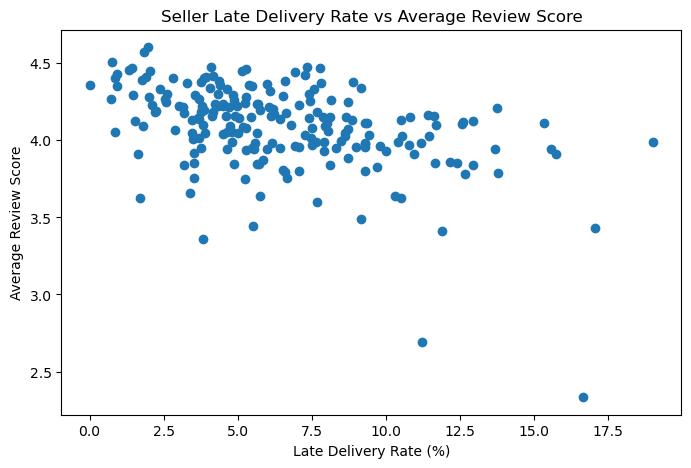

In [361]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    reliable_seller_performance["late_rate"],
    reliable_seller_performance["avg_review_score"]
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Average Review Score")
plt.title("Seller Late Delivery Rate vs Average Review Score")

plt.show()

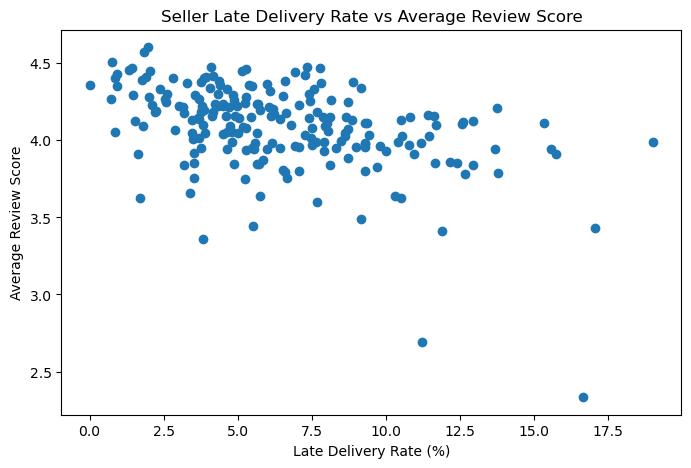

In [362]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    reliable_seller_performance["late_rate"],
    reliable_seller_performance["avg_review_score"]
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Average Review Score")
plt.title("Seller Late Delivery Rate vs Average Review Score")

plt.show()

In [363]:
customers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_customers_dataset.csv"
)

sellers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_sellers_dataset.csv"
)

In [364]:
order_geo = (
    order_items[
        ["order_id", "seller_id"]
    ]
    .drop_duplicates()
    .merge(
        orders[
            [
                "order_id",
                "customer_id",
                "delivery_days",
                "delivery_delay_days",
                "delivery_performance",
                "order_status"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        sellers[
            ["seller_id", "seller_state"]
        ],
        on="seller_id",
        how="left"
    )
)

In [365]:
order_geo = order_geo[
    order_geo["order_status"] == "delivered"
].copy()

In [366]:
order_geo.shape

(97819, 9)

In [367]:
order_geo.head()

,order_id,seller_id,customer_id,delivery_days,delivery_delay_days,delivery_performance,order_status,customer_state,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,7.0,-9.0,Early,delivered,RJ,SP
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,16.0,-3.0,Early,delivered,SP,SP
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,7.0,-14.0,Early,delivered,MG,MG
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,6.0,-6.0,Early,delivered,SP,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,25.0,-16.0,Early,delivered,SP,PR


In [368]:
order_geo["route"] = (
    order_geo["seller_state"]
    + " → "
    + order_geo["customer_state"]
)

In [369]:
top_routes = (
    order_geo["route"]
    .value_counts()
    .head(15)
)

print(top_routes)

route
SP → SP    31185
SP → RJ     8274
SP → MG     7562
SP → RS     3663
SP → PR     3164
PR → SP     2975
MG → SP     2583
SP → SC     2355
SP → BA     2340
MG → MG     1542
SP → ES     1481
SP → GO     1448
SP → DF     1398
RJ → SP     1339
SC → SP     1330
Name: count, dtype: int64


In [370]:
route_delivery = (
    order_geo
    .groupby("route")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean")
    )
)

In [371]:
route_delivery = route_delivery[
    route_delivery["orders"] >= 100
].sort_values(
    "avg_delivery_days",
    ascending=False
)

In [372]:
route_delivery.head(10)

,orders,avg_delivery_days,avg_delay_days
route,,,
SP → AL,256,24.466926,-7.961089
SP → PA,683,22.845930,-14.081395
SP → MA,493,21.601610,-9.303823
PR → BA,144,21.368056,-10.263889
SP → SE,208,20.790476,-9.466667
SP → CE,970,20.743852,-10.970287
SP → PB,337,20.147929,-12.973373
SP → RN,334,19.958209,-12.967164
SP → PI,329,19.830816,-10.607251


In [373]:
order_geo["is_late"] = (
    order_geo["delivery_delay_days"] > 0
)

In [374]:
route_performance = (
    order_geo
    .groupby("route")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
)

In [375]:
route_performance["late_rate"] = (
    route_performance["late_rate"] * 100
)

In [376]:
route_performance_reliable = route_performance[
    route_performance["orders"] >= 100
].sort_values(
    "late_rate",
    ascending=False
)

In [377]:
route_performance_reliable.head(10)

,orders,avg_delivery_days,avg_delay_days,late_rate
route,,,,
SP → AL,256,24.466926,-7.961089,23.735409
MA → SP,124,15.645161,-9.959677,20.161290
SP → MA,493,21.601610,-9.303823,18.913481
SP → PI,329,19.830816,-10.607251,16.314199
SP → SE,208,20.790476,-9.466667,16.190476
PR → BA,144,21.368056,-10.263889,14.583333
SP → RJ,8188,15.749214,-10.918419,13.983563
SP → CE,970,20.743852,-10.970287,13.627049
SP → BA,2313,19.266667,-10.857265,12.692308


### Route-Level Delivery Performance

Delivery performance varied across seller-to-customer routes.

Among routes with at least 100 delivered orders, the SP → AL route recorded the highest late-delivery rate at 23.74%, based on 256 delivered orders. Other routes such as MA → SP and SP → MA also showed relatively high late-delivery rates of 20.16% and 18.91%.

The high-volume SP → RJ route had 8,188 delivered orders and a late-delivery rate of 13.98%, showing that even major logistics corridors experienced a measurable level of late deliveries.

An important observation is that average delivery delay remained negative for all of these routes, meaning that orders were delivered earlier than the estimated date on average. Therefore, average delay alone does not fully capture late-delivery risk. Late-delivery rate provides additional insight into route-level delivery consistency.

A minimum threshold of 100 delivered orders was applied to reduce the effect of small sample sizes.

In [378]:
state_delivery = (
    order_geo
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
)

state_delivery["late_rate"] = (
    state_delivery["late_rate"] * 100
)

In [379]:
state_delivery_reliable = state_delivery[
    state_delivery["orders"] >= 1000
].sort_values(
    "late_rate",
    ascending=False
)

In [380]:
state_delivery_reliable

,orders,avg_delivery_days,avg_delay_days,late_rate
customer_state,,,,
CE,1279,20.752713,-10.885271,13.643411
BA,3256,18.809654,-10.881906,12.021858
RJ,12350,14.784978,-11.844666,11.985617
ES,1995,15.287339,-10.551929,10.583581
PE,1593,17.923221,-13.343945,9.550562
SC,3546,14.432274,-11.578874,8.110368
GO,1957,15.077465,-12.236419,6.438632
RS,5345,14.760382,-14.019111,5.970972
DF,2080,12.457740,-12.117759,5.603039


### State-Level Delivery Performance

Delivery performance varied considerably across customer states.

Among states with at least 1,000 delivered orders, Ceará (CE) recorded the highest late-delivery rate at 13.64%, followed by Bahia (BA) at 12.02% and Rio de Janeiro (RJ) at 11.99%.

São Paulo (SP), which had the largest order volume with 40,501 delivered orders, recorded a substantially lower late-delivery rate of 4.44% and an average delivery time of 8.27 days.

Average delivery time also varied significantly across states, ranging from approximately 8.27 days in SP to 20.75 days in CE within the filtered group.

These results indicate meaningful geographic differences in delivery performance. However, state-level patterns represent associations and do not establish that geography itself causes delivery delays. Factors such as seller location, route distance, logistics networks, and order characteristics may also contribute.

A minimum threshold of 1,000 delivered orders was applied to reduce the effect of small sample sizes.

In [381]:
order_geo["shipment_type"] = order_geo.apply(
    lambda row: "Same State"
    if row["seller_state"] == row["customer_state"]
    else "Interstate",
    axis=1
)

In [382]:
shipment_performance = (
    order_geo
    .groupby("shipment_type")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
        late_rate=("is_late", "mean")
    )
)

shipment_performance["late_rate"] = (
    shipment_performance["late_rate"] * 100
)

shipment_performance

,orders,avg_delivery_days,avg_delay_days,late_rate
shipment_type,,,,
Interstate,61898,14.623503,-12.816781,7.951080
Same State,34827,7.458259,-10.404764,4.453476


### Same-State vs Interstate Delivery Performance

Delivery performance differed between same-state and interstate shipments.

Interstate orders had an average delivery time of 14.62 days and a late-delivery rate of 7.95%, compared with 7.46 days and 4.45% respectively for same-state shipments.

Therefore, interstate shipments took approximately 7.17 more days on average and had a higher observed late-delivery rate than same-state shipments.

This suggests that shipment geography is associated with delivery performance in the observed data. However, the comparison does not establish that interstate shipping itself causes delays, as other factors such as route distance, seller location, logistics networks, and order characteristics may also contribute.

In [383]:
delivery_review = review_delivery[
    review_delivery["delivery_performance"] != "Not Delivered"
].copy()

In [385]:
review_delivery = reviews.merge(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_performance",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

In [386]:
review_delivery.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_days', 'delivery_performance',
       'delivery_delay_days'],
      dtype='object')

In [387]:
delivery_review = review_delivery[
    review_delivery["delivery_performance"] != "Not Delivered"
].copy()

In [388]:
delivery_review.shape

(96359, 10)

In [389]:
delivery_review["delivery_time_bucket"] = pd.cut(
    delivery_review["delivery_days"],
    bins=[0, 3, 7, 14, 21, 30, float("inf")],
    labels=[
        "1-3 days",
        "4-7 days",
        "8-14 days",
        "15-21 days",
        "22-30 days",
        "31+ days"
    ],
    include_lowest=True
)

In [390]:
delivery_review_summary = (
    delivery_review
    .groupby(
        "delivery_time_bucket",
        observed=True
    )["review_score"]
    .agg(["mean", "count"])
)

delivery_review_summary

,mean,count
delivery_time_bucket,,
1-3 days,4.459981,8596
4-7 days,4.390490,25089
8-14 days,4.288356,36396
15-21 days,4.102334,15381
22-30 days,3.493955,6865
31+ days,2.175347,4032


### Actual Delivery Time and Customer Satisfaction

Customer review scores showed a clear relationship with actual delivery duration.

Orders delivered within 1–3 days received an average review score of 4.46/5, while orders taking more than 31 days received an average score of 2.18/5.

Average review scores gradually declined as delivery duration increased:

- 1–3 days: 4.46
- 4–7 days: 4.39
- 8–14 days: 4.29
- 15–21 days: 4.10
- 22–30 days: 3.49
- 31+ days: 2.18

The difference between the fastest and slowest delivery groups was approximately 2.28 rating points.

This indicates a strong association between longer delivery duration and lower customer satisfaction in the observed data. However, the analysis does not establish that delivery time alone caused lower review scores, as other factors may also influence customer satisfaction.

In [391]:
order_items = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_items_dataset.csv"
)

sales = order_items.merge(
    orders[
        [
            "order_id",
            "order_purchase_timestamp",
            "order_status"
        ]
    ],
    on="order_id",
    how="left"
)

In [392]:
sales.shape

(112650, 9)

In [393]:
customer_orders = (
    orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

In [394]:
orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [395]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id_x', 'delivery_delay_days', 'delivery_performance',
       'delivery_days', 'customer_unique_id_y'],
      dtype='object')

In [397]:
customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [398]:
total_orders = orders["order_id"].nunique()

delivered_orders = orders[
    orders["order_status"] == "delivered"
]["order_id"].nunique()

unique_customers = customers["customer_unique_id"].nunique()

delivered_sales_value = sales.loc[
    sales["order_status"] == "delivered",
    "price"
].sum()

delivered_aov = delivered_sales_value / delivered_orders

delivered_orders_df = orders[
    orders["order_status"] == "delivered"
].copy()

avg_delivery_days = delivered_orders_df["delivery_days"].mean()

late_delivery_rate = (
    delivered_orders_df["delivery_delay_days"] > 0
).mean() * 100

avg_review_score = reviews["review_score"].mean()

repeat_customer_rate = (
    (customer_orders > 1).sum()
    / unique_customers
) * 100

In [399]:
kpi_summary = {
    "Total Orders": total_orders,
    "Delivered Orders": delivered_orders,
    "Unique Customers": unique_customers,
    "Delivered Sales Value": round(delivered_sales_value, 2),
    "Delivered AOV": round(delivered_aov, 2),
    "Average Delivery Days": round(avg_delivery_days, 2),
    "Late Delivery Rate": round(late_delivery_rate, 2),
    "Average Review Score": round(avg_review_score, 2),
    "Repeat Customer Rate": round(repeat_customer_rate, 2)
}

kpi_summary

{'Total Orders': 99441,
 'Delivered Orders': 96478,
 'Unique Customers': 96096,
 'Delivered Sales Value': np.float64(13221498.11),
 'Delivered AOV': np.float64(137.04),
 'Average Delivery Days': np.float64(12.09),
 'Late Delivery Rate': np.float64(6.77),
 'Average Review Score': np.float64(4.09),
 'Repeat Customer Rate': np.float64(3.12)}

# Executive Summary

## Business Overview

This project analyzes the Brazilian E-Commerce Public Dataset by Olist to understand e-commerce sales performance, customer behavior, product and category performance, delivery operations, seller performance, payment behavior, and customer satisfaction.

The analysis combines order, product, customer, seller, payment, review, and logistics data to identify important business patterns and potential areas for improvement.

## Key Performance Indicators

| KPI | Value |
|---|---:|
| Total Orders | 99,441 |
| Delivered Orders | 96,478 |
| Unique Customers | 96,096 |
| Delivered Sales Value | 13,221,498.11 |
| Delivered AOV | 137.04 |
| Average Delivery Time | 12.09 days |
| Late Delivery Rate | 6.77% |
| Average Review Score | 4.09 / 5 |
| Repeat Customer Rate | 3.12% |

> Note: Delivered Sales Value is calculated using the product `price` field for delivered orders and is treated as a sales-value/GMV proxy. It is not interpreted as accounting revenue or profit.

## Key Business Findings

### 1. Sales Performance

Sales activity increased substantially throughout the observed period. Monthly delivered product sales value reached approximately 1.01 million in November 2017 and remained close to 1 million during several months in early 2018.

Average Order Value remained relatively stable across major business months, generally around 125–150. This indicates that changes in monthly sales were influenced substantially by order volume rather than large changes in average order value.

### 2. Customer Behavior

The dataset contains 96,096 unique customers.

Approximately 96.88% of customers placed only one order, while 3.12% placed multiple orders. Among repeat customers, the average number of orders was approximately 2.12.

This represents observed repeat purchasing during the dataset period and should not be interpreted as a direct measure of long-term customer retention because customers who purchased near the end of the observation period had less opportunity to purchase again.

### 3. Delivery Performance

The average delivery time was 12.09 days for delivered orders.

The overall late-delivery rate among delivered orders was 6.77%.

Delivery performance varied substantially across months, states, sellers, and shipment routes. March 2018 recorded an 18.42% late-delivery rate among meaningful monthly order volumes, indicating a period that warrants further investigation.

Interstate shipments also took longer on average than same-state shipments:

- Interstate: 14.62 days average delivery time
- Same State: 7.46 days average delivery time

### 4. Customer Satisfaction

The overall average review score was 4.09 out of 5.

Customer satisfaction showed a strong association with delivery performance. Early deliveries had an average review score of 4.29, compared with 2.27 for late deliveries and 1.76 for orders classified as not delivered.

Actual delivery duration also showed a clear relationship with customer satisfaction. Orders delivered within 1–3 days received an average score of 4.46, while orders taking more than 31 days received an average score of 2.18.

These relationships represent associations in the observed data and do not establish causation.

### 5. Product and Category Performance

Product category performance varied across sales value, order volume, and order-based AOV.

Health & Beauty generated the highest delivered sales value among categories at approximately 1.23 million, while Bed, Bath & Table recorded the highest number of delivered orders at 9,272.

The top five categories accounted for approximately 40.35% of delivered product sales value among categorized products.

At the product level, the top 10 products by delivered sales value contributed approximately 3.35% of total delivered product sales value, indicating that sales were not concentrated in a very small number of individual products.

### 6. Seller Performance

Seller performance varied across sales value, order volume, AOV, delivery consistency, and customer satisfaction.

Among sellers with at least 100 delivered orders, the highest observed order-based AOV was approximately 626.27.

Seller-level analysis also showed a moderate negative correlation between late-delivery rate and average review score (Pearson correlation = -0.446) among sellers with at least 100 delivered orders and 100 reviews.

This suggests that sellers with higher late-delivery rates tended to have lower average review scores in the observed data. However, correlation does not establish causation.

### 7. Geographic and Logistics Patterns

Delivery performance varied across customer states and seller-to-customer routes.

Among states with at least 1,000 delivered orders, Ceará recorded the highest late-delivery rate at 13.64%, while São Paulo recorded a 4.44% late-delivery rate across 40,501 delivered orders.

Route-level analysis also showed differences in late-delivery rates. Among routes with at least 100 delivered orders, SP → AL recorded a 23.74% late-delivery rate based on 256 delivered orders.

These geographic differences may warrant further investigation into logistics networks, route characteristics, seller locations, and delivery operations.

## Business Recommendations

Based on the analysis, the following areas could be investigated further:

1. **Investigate high late-delivery periods**  
   Examine operational and logistics factors behind months with unusually high late-delivery rates, particularly March 2018.

2. **Monitor high-risk routes**  
   Track routes with consistently high late-delivery rates and investigate whether distance, seller location, or logistics networks contribute to delays.

3. **Improve delivery consistency**  
   Focus on reducing severe delivery delays because longer actual delivery times were strongly associated with lower review scores.

4. **Monitor seller-level delivery performance**  
   Evaluate sellers using multiple metrics such as order volume, sales value, AOV, late-delivery rate, and customer reviews rather than relying on a single KPI.

5. **Investigate category-level customer experience**  
   Categories with relatively low review scores can be examined further to identify whether delivery, product quality, seller performance, or other factors contribute to customer dissatisfaction.

6. **Explore customer repeat purchasing**  
   Since most observed customers placed only one order, further analysis could investigate repeat-purchase patterns by category, geography, order value, and purchase timing.

7. **Use geographic insights for logistics planning**  
   Differences between same-state and interstate delivery performance suggest that geographic and route-level metrics can be useful for monitoring logistics operations.

In [402]:
sales["purchase_month"] = (
    sales["order_purchase_timestamp"].dt.to_period("M")
)

In [403]:
sales.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'order_purchase_timestamp', 'order_status', 'purchase_month'],
      dtype='object')

In [404]:
monthly_sales = (
    sales[sales["order_status"] == "delivered"]
    .groupby("purchase_month")["price"]
    .sum()
)

monthly_sales = monthly_sales[
    (monthly_sales.index >= "2017-01") &
    (monthly_sales.index <= "2018-08")
]

monthly_sales

purchase_month
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64

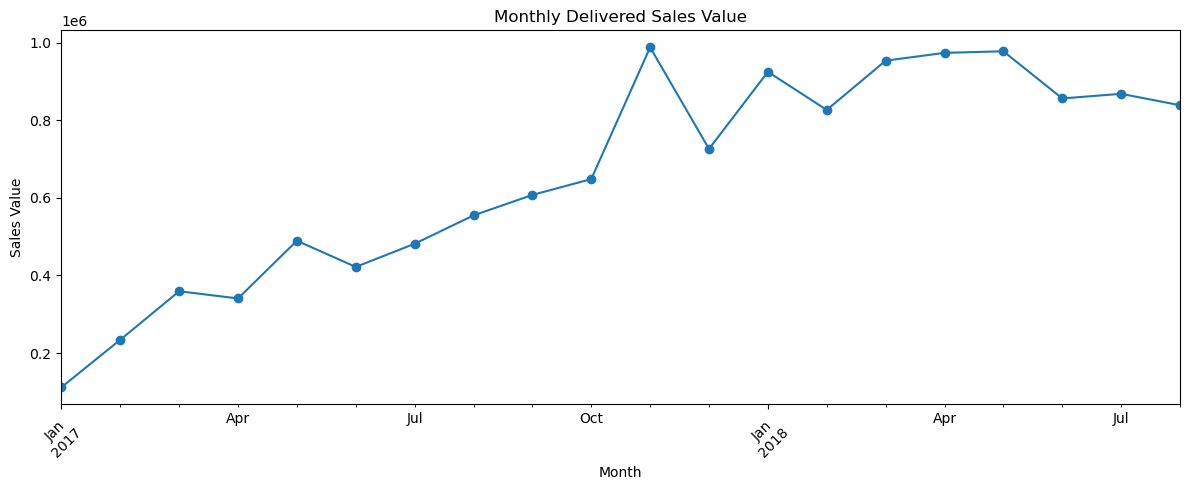

In [405]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    title="Monthly Delivered Sales Value"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [406]:
delivery_counts = (
    orders["delivery_performance"]
    .value_counts()
)

delivery_counts

delivery_performance
Early            88649
Late              6535
Not Delivered     2965
On Time           1292
Name: count, dtype: int64

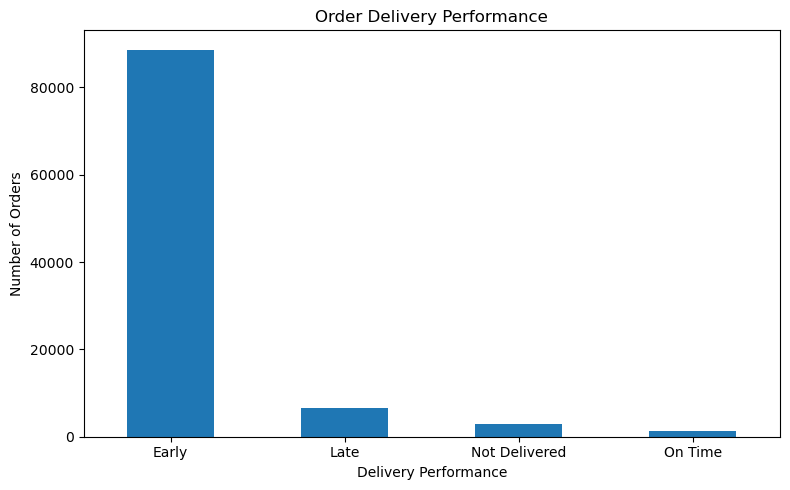

In [407]:
delivery_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Order Delivery Performance"
)

plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Delivery Performance

Most orders were delivered earlier than the estimated delivery date.

Among delivered orders, the late-delivery rate was 6.77%. However, the analysis also identified 2,965 orders without a recorded customer delivery date, which were classified separately as "Not Delivered".

Late deliveries were associated with substantially lower customer review scores, highlighting delivery performance as an important customer-experience metric.

In [408]:
category_summary.head()

,sales_value,orders,aov
category_english,,,
health_beauty,1233131.72,8647,142.608040
watches_gifts,1166176.98,5495,212.225110
bed_bath_table,1023434.76,9272,110.379072
sports_leisure,954852.55,7530,126.806448
computers_accessories,888724.61,6530,136.098715


In [410]:
sales.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'order_purchase_timestamp', 'order_status', 'purchase_month'],
      dtype='object')

In [411]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [412]:
products = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_products_dataset.csv"
)

In [413]:
category_translation = pd.read_csv(
    "C:/Users/A/Downloads/archive/product_category_name_translation.csv"
)

In [419]:
sales = sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [ ]:
category_summary.head(10)

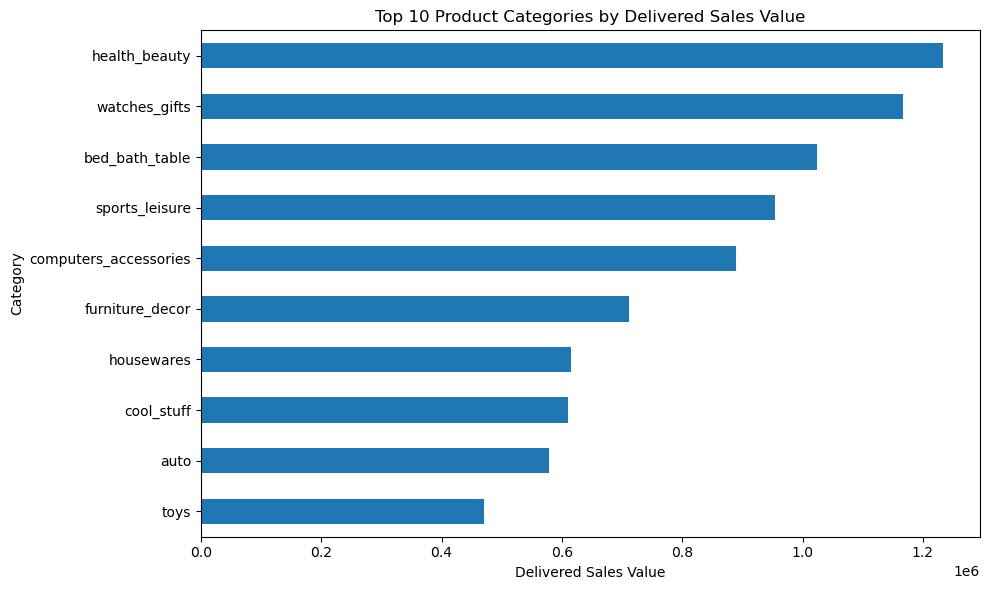

In [421]:
top_categories = category_summary.head(10)

top_categories["sales_value"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Product Categories by Delivered Sales Value"
)

plt.xlabel("Delivered Sales Value")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [422]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [423]:
reviews = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_reviews_dataset.csv"
)

In [424]:
review_delivery = reviews.merge(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_performance",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

In [425]:
delivery_review = review_delivery[
    review_delivery["delivery_performance"] != "Not Delivered"
].copy()

In [426]:
delivery_review["delivery_time_bucket"] = pd.cut(
    delivery_review["delivery_days"],
    bins=[0, 3, 7, 14, 21, 30, float("inf")],
    labels=[
        "1-3 days",
        "4-7 days",
        "8-14 days",
        "15-21 days",
        "22-30 days",
        "31+ days"
    ],
    include_lowest=True
)

In [427]:
delivery_review_summary = (
    delivery_review
    .groupby(
        "delivery_time_bucket",
        observed=True
    )["review_score"]
    .agg(["mean", "count"])
)

delivery_review_summary

,mean,count
delivery_time_bucket,,
1-3 days,4.459981,8596
4-7 days,4.390490,25089
8-14 days,4.288356,36396
15-21 days,4.102334,15381
22-30 days,3.493955,6865
31+ days,2.175347,4032


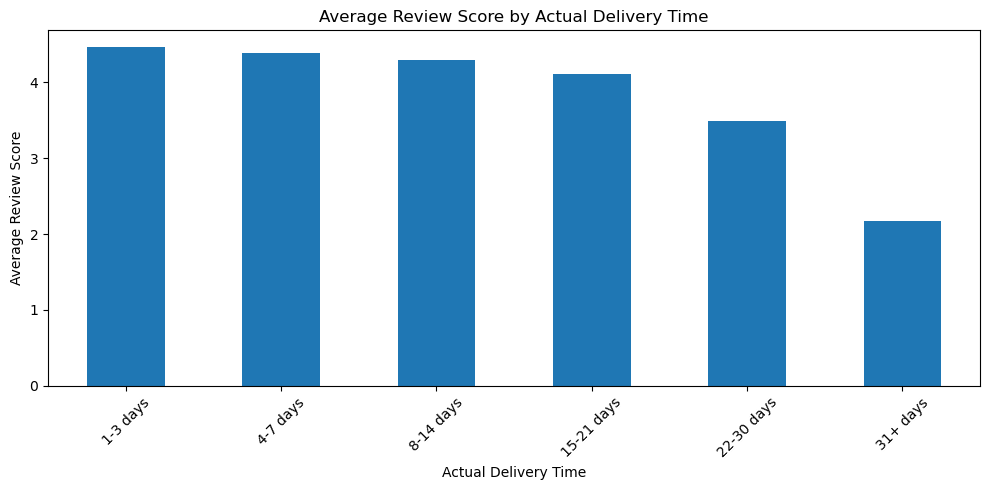

In [428]:
delivery_review_summary["mean"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Review Score by Actual Delivery Time"
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Average Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Delivery Time and Customer Satisfaction

Customer review scores declined as actual delivery duration increased.

Orders delivered within 1–3 days received an average review score of 4.46/5, while orders taking more than 31 days received an average score of 2.18/5.

Average review scores declined progressively across the delivery-time groups, indicating a strong association between longer delivery duration and lower customer satisfaction in the observed data.

The difference between the fastest and slowest delivery groups was approximately 2.28 rating points.

This analysis shows association rather than causation. Other factors may also influence customer review scores.

### Customer Purchase Frequency

Customer purchasing was highly concentrated around one-time purchases.

Out of 96,096 unique customers, 93,099 customers (96.88%) placed only one order, while 2,997 customers (3.12%) placed multiple orders.

This indicates that repeat purchasing represented a relatively small portion of the observed customer base during the dataset period.

The finding highlights customer retention and repeat-purchase behavior as an area that could be investigated further.

This should not be interpreted as a direct customer retention rate because the dataset covers a historical observation period and does not provide a defined retention window.

In [431]:
state_customer_counts = (
    customers.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

state_customer_counts

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
Name: customer_unique_id, dtype: int64

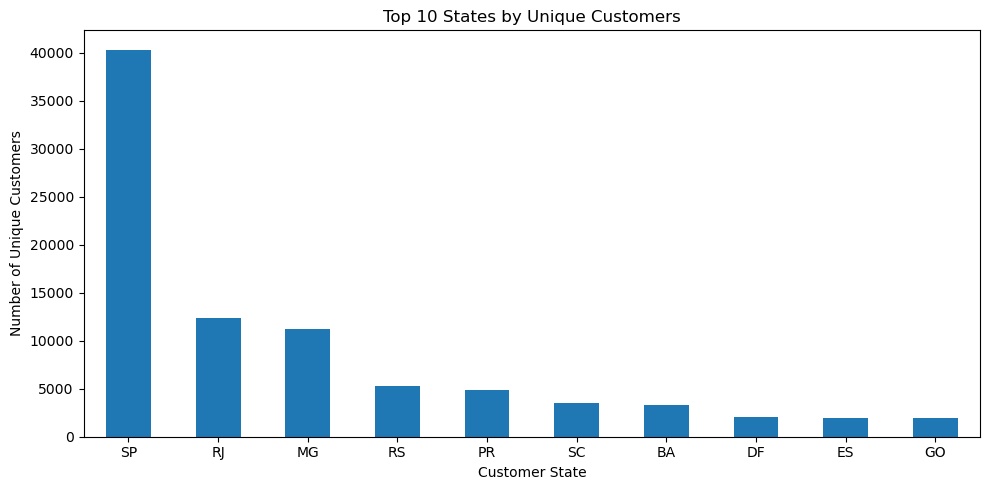

In [432]:
state_customer_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 States by Unique Customers"
)

plt.xlabel("Customer State")
plt.ylabel("Number of Unique Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Customer Geographic Distribution

The customer base was geographically concentrated in a small number of Brazilian states.

São Paulo represented approximately 41.92% of unique customers, followed by Rio de Janeiro at 12.88% and Minas Gerais at 11.71%.

The concentration of customers in these states indicates that regional market characteristics and logistics coverage are important considerations when evaluating sales and delivery performance.

This analysis describes the observed customer distribution and does not by itself explain the reasons for the geographic concentration.

In [433]:
payment_type_counts = (
    payments["payment_type"]
    .value_counts()
)

payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [434]:
payments = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_order_payments_dataset.csv"
)

payments.shape

(103886, 5)

In [435]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [436]:
payment_type_counts = (
    payments["payment_type"]
    .value_counts()
)

payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

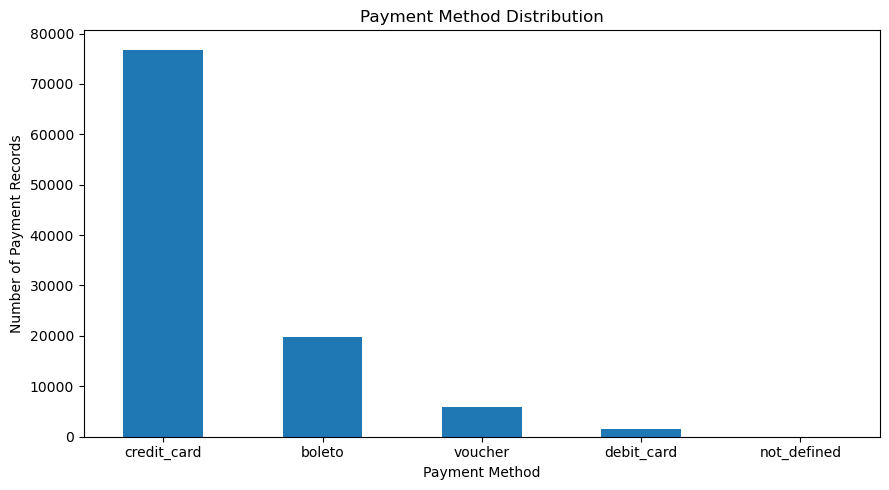

In [437]:
payment_type_counts.plot(
    kind="bar",
    figsize=(9, 5),
    title="Payment Method Distribution"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Payment Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

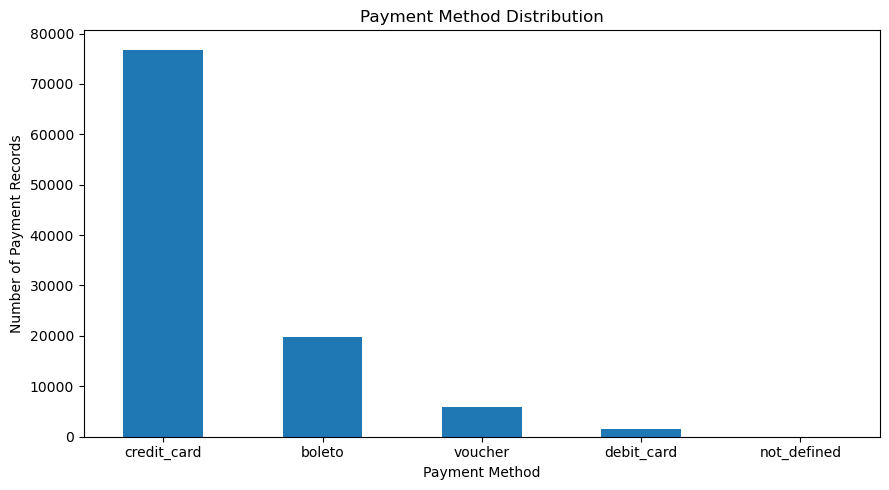

In [438]:
payment_type_counts.plot(
    kind="bar",
    figsize=(9, 5),
    title="Payment Method Distribution"
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Payment Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Payment Method Distribution

Credit card was the dominant payment method in the dataset, accounting for approximately 73.92% of payment records.

Boleto was the second most common payment method at approximately 19.04%, while voucher and debit card represented smaller shares.

These figures are based on payment records rather than unique customers or orders. An order can contain multiple payment records, so payment-record percentages should not be interpreted directly as customer-level payment preferences.

In [439]:
review_score_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_score_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

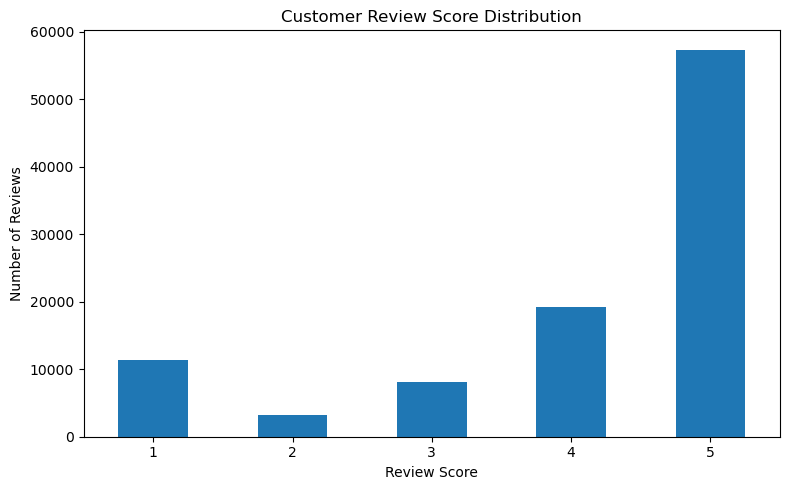

In [440]:
review_score_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Review Score Distribution"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Customer Review Score Distribution

Customer reviews were generally positive, with an average review score of 4.09 out of 5.

Five-star reviews represented approximately 57.78% of all review records, while 77.07% of reviews were rated 4 or 5 stars.

However, 14.69% of reviews were rated 1 or 2 stars, representing a meaningful group of dissatisfied customers.

The distribution suggests that overall customer satisfaction was relatively positive, while the low-rating segment provides an opportunity for further investigation into issues such as delivery, product quality, and seller performance.

In [442]:
sales = sales.merge(
    orders[
        [
            "order_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

In [443]:
sales[
    ["order_id", "delivery_days", "delivery_delay_days"]
].head()

,order_id,delivery_days,delivery_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,7.0,-9.0
1,00018f77f2f0320c557190d7a144bdd3,16.0,-3.0
2,000229ec398224ef6ca0657da4fc703e,7.0,-14.0
3,00024acbcdf0a6daa1e931b038114c75,6.0,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,25.0,-16.0


In [444]:
seller_order_delivery = (
    sales[
        sales["order_status"] == "delivered"
    ][
        [
            "seller_id",
            "order_id",
            "delivery_days",
            "delivery_delay_days"
        ]
    ]
    .drop_duplicates(["seller_id", "order_id"])
)

seller_order_delivery["is_late"] = (
    seller_order_delivery["delivery_delay_days"] > 0
)

In [445]:
seller_delivery = (
    seller_order_delivery
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        late_rate=("is_late", "mean")
    )
)

seller_delivery["late_rate"] = (
    seller_delivery["late_rate"] * 100
)

In [446]:
seller_delivery_reliable = (
    seller_delivery[
        seller_delivery["orders"] >= 100
    ]
    .sort_values("late_rate", ascending=False)
    .head(10)
)

seller_delivery_reliable

,orders,late_rate
seller_id,,
06a2c3af7b3aee5d69171b0e14f0ee87,389,19.023136
88460e8ebdecbfecb5f9601833981930,246,17.073171
1ca7077d890b907f89be8c954a02686a,108,16.666667
e5a3438891c0bfdb9394643f95273d8e,216,15.740741
cd68562d3f44870c08922d380acae552,122,15.573770
2c9e548be18521d1c43cde1c582c6de8,124,15.322581
431af27f296bc6519d890aa5a05fdb11,116,13.793103
f7ba60f8c3f99e7ee4042fdef03b70c4,218,13.761468
8160255418d5aaa7dbdc9f4c64ebda44,380,13.684211


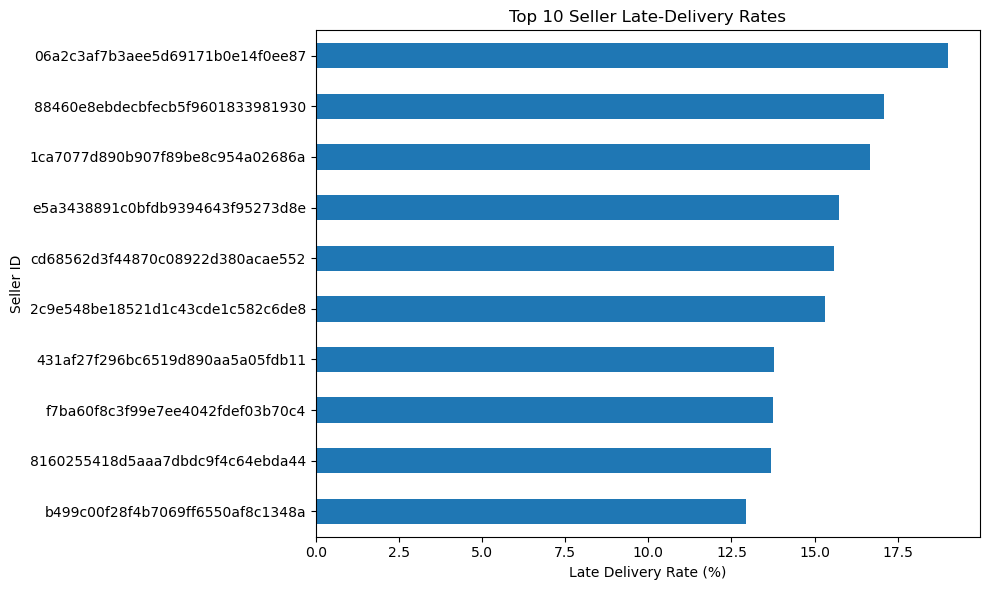

In [447]:
seller_delivery_reliable["late_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Seller Late-Delivery Rates"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

In [448]:
customers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_customers_dataset.csv"
)

customers.shape

(99441, 5)

In [449]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [450]:
orders = orders.merge(
    customers[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

In [451]:
orders = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_orders_dataset.csv"
)

orders.shape

(99441, 8)

In [452]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [453]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["estimated_delivery_days"] = (
    orders["order_estimated_delivery_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [454]:
customers = pd.read_csv(
    "C:/Users/A/Downloads/archive/olist_customers_dataset.csv"
)

customers.shape

(99441, 5)

In [455]:
orders = orders.merge(
    customers[
        ["customer_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

In [456]:
orders[
    [
        "order_id",
        "order_status",
        "customer_state",
        "delivery_days",
        "delivery_delay_days"
    ]
].head()

,order_id,order_status,customer_state,delivery_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,8.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,13.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,9.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,13.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,2.0,-10.0


In [457]:
state_delivery = (
    orders[
        orders["order_status"] == "delivered"
    ]
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=(
            "delivery_delay_days",
            lambda x: (x > 0).mean() * 100
        )
    )
)

state_delivery

,orders,avg_delivery_days,late_rate
customer_state,,,
AC,80,20.637500,3.750000
AL,397,24.040302,21.410579
AM,145,25.986207,2.758621
AP,67,26.731343,2.985075
BA,3256,18.866400,12.162162
CE,1279,20.817826,13.760751
DF,2080,12.509135,5.673077
ES,1995,15.331830,10.726817
GO,1957,15.150741,6.540623


In [458]:
state_delivery_reliable = (
    state_delivery[
        state_delivery["orders"] >= 1000
    ]
    .sort_values("late_rate", ascending=False)
)

state_delivery_reliable

,orders,avg_delivery_days,late_rate
customer_state,,,
CE,1279,20.817826,13.760751
BA,3256,18.866400,12.162162
RJ,12350,14.848583,12.105263
ES,1995,15.331830,10.726817
PE,1593,17.965474,9.604520
SC,3546,14.475183,8.206430
GO,1957,15.150741,6.540623
RS,5345,14.819237,6.080449
DF,2080,12.509135,5.673077


In [459]:
import matplotlib.pyplot as plt

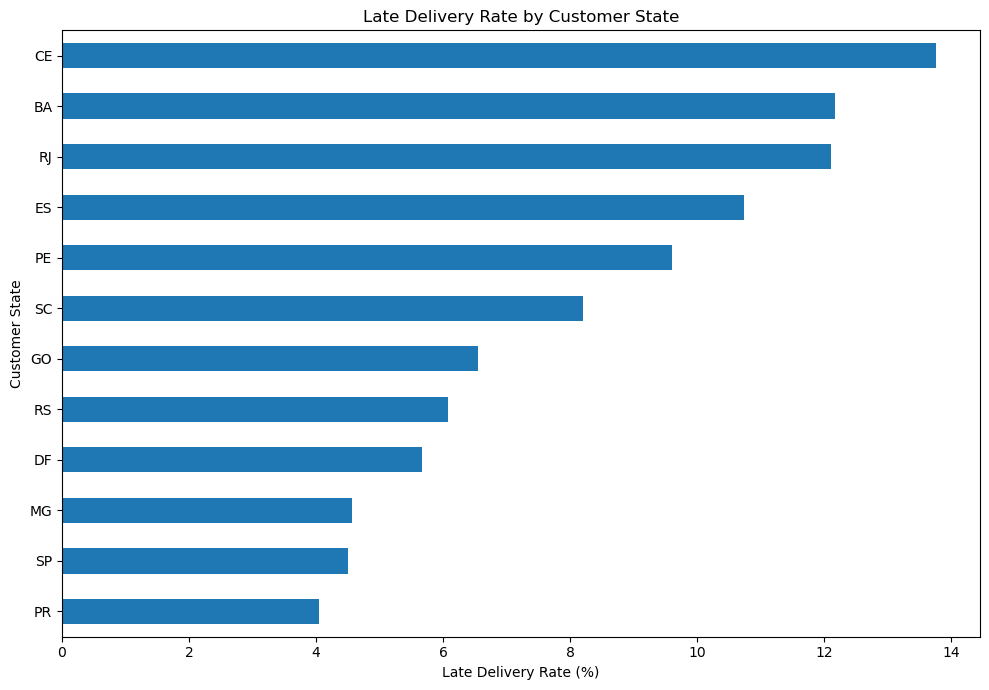

In [460]:
state_delivery_reliable["late_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 7),
    title="Late Delivery Rate by Customer State"
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

# Executive Summary

## Business Overview

This project analyzes the Brazilian E-Commerce Public Dataset by Olist, containing approximately 99,000 orders and related information on customers, products, sellers, payments, reviews, and delivery performance.

The objective was to evaluate sales performance, customer behavior, product and category performance, delivery operations, seller performance, and customer satisfaction to identify meaningful business insights.

## Key Performance Indicators

| KPI | Value |
|---|---:|
| Total Orders | 99,441 |
| Delivered Orders | 96,478 |
| Unique Customers | 96,096 |
| Delivered Sales Value | 13.22M |
| Delivered AOV | 137.04 |
| Average Delivery Time | 12.09 days |
| Late Delivery Rate | 6.77% |
| Average Review Score | 4.09 / 5 |
| Repeat Customer Rate | 3.12% |

> Product price is used as a sales-value/GMV proxy in this analysis. It should not be interpreted as accounting revenue or profit.

## Key Business Insights

### 1. Sales Performance

Delivered orders generated approximately 13.22M in product sales value across 96,478 delivered orders.

Monthly delivered sales increased substantially during the observed period, with several major business months reaching close to 1M in sales value.

Average Order Value generally remained within a relatively stable range across major business months, suggesting that sales growth was driven primarily by order volume rather than major increases in order value.

### 2. Customer Behavior

Customer purchasing was highly concentrated around one-time purchases.

Approximately 96.88% of unique customers placed only one order, while 3.12% placed multiple orders.

This indicates that repeat purchasing represented a relatively small portion of the observed customer base.

### 3. Product and Category Performance

Health & Beauty generated the highest delivered sales value among categories at approximately 1.23M.

Watches & Gifts generated approximately 1.17M, while Bed, Bath & Table generated approximately 1.02M.

Bed, Bath & Table recorded the highest delivered order volume with 9,272 orders.

The top 10 products contributed approximately 3.35% of delivered product sales value, indicating that sales were relatively distributed across products rather than being dominated by a small number of products.

### 4. Delivery Performance

Among delivered orders, approximately 6.77% were delivered later than the estimated delivery date.

The median delivery delay among late orders was 7 days.

March 2018 recorded an 18.42% late-delivery rate among approximately 7,200 orders, making it an important period for further operational investigation.

Interstate shipments had an average delivery time of approximately 14.62 days compared with 7.46 days for same-state shipments.

### 5. Customer Satisfaction

The overall average review score was 4.09 out of 5.

Approximately 77.07% of reviews were rated 4 or 5 stars, while 14.69% were rated 1 or 2 stars.

Customer satisfaction showed a strong association with delivery performance.

Early deliveries had an average review score of approximately 4.29, compared with 2.27 for late deliveries and 1.76 for orders that were not delivered.

Actual delivery duration also showed a strong association with satisfaction: orders delivered within 1–3 days averaged 4.46, while orders taking more than 31 days averaged 2.18.

These relationships indicate association rather than causation.

### 6. Seller Performance

Seller-level delivery performance varied considerably.

Among sellers with at least 100 delivered orders, the highest observed late-delivery rate was approximately 19.02%.

Seller performance should therefore be evaluated using multiple metrics, including order volume, late-delivery rate, delivery time, and customer review scores.

### 7. Geographic and Logistics Performance

The customer base was geographically concentrated.

São Paulo represented approximately 41.92% of unique customers, followed by Rio de Janeiro at 12.88% and Minas Gerais at 11.71%.

Delivery performance also varied geographically. Among states with at least 1,000 delivered orders, Ceará recorded an observed late-delivery rate of approximately 13.64%, while Paraná recorded approximately 3.99%.

These geographic differences describe observed patterns and do not establish that location itself causes delivery delays.

## Overall Business Interpretation

The analysis indicates that the marketplace had strong sales growth and generally positive customer reviews, but several areas require attention.

The most important areas identified are:

- Low observed repeat-purchase rate
- Delivery delays in specific periods and regions
- Strong relationship between delivery performance and customer satisfaction
- Variation in seller delivery performance
- Geographic differences in delivery outcomes

These findings provide opportunities for further investigation into customer retention, logistics operations, seller performance, and regional delivery strategies.

# Business Recommendations

Based on the analysis, the following recommendations can help improve customer experience, operational performance, and business growth.

## 1. Improve Delivery Performance

Late deliveries were associated with substantially lower customer review scores.

The business should monitor late-delivery rates regularly and investigate periods with unusually high delays, particularly the increase observed during early 2018.

**Recommended actions:**
- Monitor late-delivery rate by month.
- Identify orders approaching their estimated delivery date.
- Investigate operational bottlenecks during high-volume periods.
- Track delivery performance by seller, region, and route.

---

## 2. Focus on High-Risk Geographic Routes

Delivery performance varied considerably across customer states and shipping routes.

Interstate shipments also showed longer average delivery times and higher late-delivery rates than same-state shipments.

**Recommended actions:**
- Identify routes with consistently high late-delivery rates.
- Review logistics partners and transportation capacity on high-risk routes.
- Consider regional fulfillment or strategically located inventory where appropriate.
- Monitor geographic delivery KPIs continuously.

---

## 3. Monitor Seller Delivery Performance

Seller-level analysis showed considerable variation in late-delivery rates.

A seller with high order volume but poor delivery performance can have a significant impact on overall customer experience.

**Recommended actions:**
- Create seller-level delivery dashboards.
- Track late-delivery rate, average delivery time, and order volume together.
- Investigate consistently underperforming sellers.
- Recognize sellers with strong operational performance.

Seller comparisons should use minimum order thresholds to avoid misleading results from very small samples.

---

## 4. Improve Customer Retention

Approximately 96.88% of observed unique customers placed only one order, while only 3.12% placed multiple orders.

This suggests an opportunity to investigate strategies that encourage customers to purchase again.

**Recommended actions:**
- Develop targeted repeat-purchase campaigns.
- Recommend related products after a purchase.
- Offer incentives for subsequent purchases.
- Analyze customer segments based on purchasing behavior.
- Investigate whether delivery experience influences repeat purchasing.

The observed repeat-purchase rate is based on the historical dataset and should not be interpreted as a formal customer retention rate.

---

## 5. Protect Customer Satisfaction

Delivery performance showed a strong association with customer review scores.

Late and undelivered orders had substantially lower average ratings than early deliveries.

**Recommended actions:**
- Prioritize delayed orders for customer communication.
- Provide accurate delivery estimates.
- Notify customers proactively when delays occur.
- Analyze low-rated orders to identify recurring operational problems.
- Monitor customer satisfaction alongside delivery KPIs.

These relationships indicate association and do not by themselves establish causation.

---

## 6. Monitor Category Performance

Different categories showed different combinations of sales value, order volume, and order-based AOV.

Therefore, category performance should not be evaluated using sales value alone.

**Recommended actions:**
- Track sales value by category.
- Track order volume by category.
- Monitor category-level AOV.
- Identify high-volume categories for operational planning.
- Identify high-value categories for targeted marketing and merchandising.

---

## 7. Use Multiple KPIs for Business Decisions

A single KPI can hide important business patterns.

For example, a seller may generate high sales but also have a relatively high late-delivery rate.

A balanced performance framework should therefore include:

- Sales value
- Order volume
- Average Order Value
- Delivery time
- Late-delivery rate
- Customer review score
- Repeat-purchase behavior

Using multiple KPIs provides a more complete view of business performance.

---

# Final Business Takeaway

The analysis shows that the marketplace had strong sales activity and generally positive customer ratings, but operational performance and customer retention provide important opportunities for improvement.

The strongest relationships identified in the analysis were between:

**Delivery Performance → Customer Satisfaction**

and

**Geographic / Seller Factors → Delivery Performance**

At the same time, the relatively low observed repeat-purchase rate highlights the importance of understanding customer retention and post-purchase behavior.

The next stage of analysis can investigate these relationships statistically and determine whether the observed patterns are statistically significant.

In [461]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,delivery_delay_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,15,-8.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,19,-6.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,26,-18.0,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,26,-13.0,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,12,-10.0,SP


In [462]:
import matplotlib.pyplot as plt